
#### DAMG6105 Data Science Engineering with Python

Instructor: Dr. Handan Liu

#### Submission Instructions
Submit this `ipynb` file via Canvas.  To ensure that your submitted files represent your latest code, make sure to give a fresh `Kernel > Restart Kerne and Run All` just before submitting files. 

## Project 1: Bluebikes Station Imbalance Analysis


### Your name: Linlin Fan

In [1]:
import numpy as np
import pandas as pd

## Project Background

Bluebikes began in 2011 as Hubway, launching with 60 stations in Boston. It has since grown into a large regional bike-sharing system with nearly 400 stations and 4,000 bikes across 10 municipalities. In this project, you will use real Bluebikes data to investigate whether station bike availability behaves differently during the morning commute and evening commute, and whether these patterns show meaningful spatial structure across the city.

### Data Sources

Use the following data:

- Bluebikes trip data for August, September, and October 2025
- https://s3.amazonaws.com/hubway-data/index.html
- Bluebikes system/station website to understand the meaning of the features and fields.
- https://bluebikes.com/system-data


You should download and study the data specified in the project description.

### Main Question

Do Boston Bluebikes stations show significant differences in bike storage behavior between:

- Morning peak: 7:00-9:00 AM
- Evening peak: 4:00-7:00 PM
  

You must address the following:

1. Morning vs. Evening Difference
  - Is there a significant difference in station-level bike storage behavior between morning peak and evening peak?
2. Empty-Station Risk
  - Which stations are more likely to become “empty” during the morning peak?
  - Interpret “empty” as a station likely to experience a shortage of available bikes.
3. Full-Station Risk
  - Which stations are more likely to become “full” during the evening peak?
  - Interpret “full” as a station likely to experience a shortage of available docks.
4. Spatial Clustering
  - Do these phenomena show spatial clustering?
  - For example, do patterns differ between downtown/commercial areas and residential areas?
5. Visualization
  - Use standard visualization methods to communicate your results clearly.


### Optional Extensions

If you can't solve the above questions well, you can also explore other interesting problems supported by data features. As long as these problems are based on data and have good reasoning, they can also help you get a good score.


### Bonus Question

Map-based visualization:
- Display your findings on a map, highlighting in particular the risk of empty stations in the morning, full stations in the evening, or supply-demand imbalances during peak hours at the station level.

## Suggested Technical Workflow

Students may use:
- Python
- pandas
- numpy
- matplotlib / seaborn / plotly
- geopandas / folium / plotly mapbox for maps if desired


A reasonable workflow is:

- Load August, September, October 2025 files
- Merge and clean
- Parse timestamps
- Filter Boston-area or all Bluebikes stations, depending on your chosen scope
- Extract morning and evening peak trips
- Compute departures, arrivals, and net flow by station
- Rank stations by imbalance
- Compare patterns across time windows
- Visualize results
- Interpret spatial structure
- ....

# Your work:

### - Load August, September, October 2025 files

In [2]:
aug_data = pd.read_csv('202508-bluebikes-tripdata.csv', parse_dates=True)
aug_data.head(5)

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,4436F9636EB63A25,classic_bike,2025-08-19 07:35:27.830,2025-08-19 07:45:58.788,Newbury St at Hereford St,B32000,South Station - 700 Atlantic Ave,A32010,42.348717,-71.085954,42.352175,-71.055547,member
1,07982D9C43A5F471,electric_bike,2025-08-19 08:19:35.451,2025-08-19 08:38:54.573,Foss Park,S32015,South Station - 700 Atlantic Ave,A32010,42.391035,-71.090420,42.352175,-71.055547,member
2,7F2823FDF0AB5F34,classic_bike,2025-08-20 07:45:16.086,2025-08-20 07:56:40.386,Newbury St at Hereford St,B32000,South Station - 700 Atlantic Ave,A32010,42.348717,-71.085954,42.352175,-71.055547,member
3,FFEC9360D8966C39,classic_bike,2025-08-21 07:41:15.140,2025-08-21 07:53:14.966,Newbury St at Hereford St,B32000,South Station - 700 Atlantic Ave,A32010,42.348717,-71.085954,42.352175,-71.055547,member
4,CDC94574FEF9CF7D,classic_bike,2025-08-22 07:44:10.700,2025-08-22 07:56:41.044,Newbury St at Hereford St,B32000,South Station - 700 Atlantic Ave,A32010,42.348717,-71.085954,42.352175,-71.055547,member


In [3]:
sep_data = pd.read_csv('202509-bluebikes-tripdata.csv', parse_dates=True)
sep_data.head(5)

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,141F6366FDD45720,electric_bike,2025-09-20 09:32:51.460,2025-09-20 09:35:02.699,Everett Square (Broadway at Norwood St),V32003,Swan St. Park,V32007,42.407381,-71.055356,42.412505,-71.058422,member
1,E9A55253A0B9B86B,classic_bike,2025-09-17 11:20:09.980,2025-09-17 11:41:39.436,Commonwealth Ave at Agganis Way,A32002,Nubian Square - Bolling Building,B32017,42.351692,-71.119035,42.329843,-71.083866,member
2,95834E3240C1DB01,classic_bike,2025-09-17 07:37:55.648,2025-09-17 07:42:40.162,Dudley Town Common - Mt Pleasant Ave at Blue H...,C32015,Nubian Square - Bolling Building,B32017,42.325333,-71.075354,42.329843,-71.083866,member
3,2306ACEED3C59AD3,classic_bike,2025-09-19 11:30:08.688,2025-09-19 11:51:49.018,Commonwealth Ave at Agganis Way,A32002,Nubian Square - Bolling Building,B32017,42.351692,-71.119035,42.329843,-71.083866,member
4,19DA9CCCF92803E1,electric_bike,2025-09-08 20:02:28.834,2025-09-08 20:25:48.120,Ryan Playground - Dorchester Ave at Harbor Vie...,C32031,Ryan Playground - Dorchester Ave at Harbor Vie...,C32031,42.317779,-71.056703,42.317642,-71.056664,member


In [4]:
oct_data = pd.read_csv('202510-bluebikes-tripdata.csv', parse_dates=True)
oct_data.head(5)

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,E0D79E326B05504C,classic_bike,2025-10-26 02:28:51.464,2025-10-26 02:41:07.460,Park Plaza at Charles St S.,D32042,Deerfield St at Commonwealth Ave,B32037,42.351828,-71.067811,42.349244,-71.097282,casual
1,86AFD5D6B723CEEA,classic_bike,2025-10-23 08:31:04.944,2025-10-23 08:44:37.461,South End Library - Tremont St at W Newton St,A32009,MIT Carleton St at Amherst St,M32070,42.341332,-71.076847,42.360542,-71.086698,member
2,65D2E544185C06B0,electric_bike,2025-10-16 21:21:52.118,2025-10-16 21:39:28.641,Washington St at Peters Park,C32067,Green Street T Stop - Green St at Amory St,E32005,42.342935,-71.067063,42.310579,-71.107341,member
3,3592D59C8B8DC601,electric_bike,2025-10-21 07:50:31.868,2025-10-21 08:01:36.350,Somerville City Hall Annex,S32036,Mass Ave/Lafayette Square,M32085,42.391898,-71.097454,42.363565,-71.100442,member
4,89DE10D75CFFB399,electric_bike,2025-10-22 06:48:50.057,2025-10-22 06:58:36.149,30 Dane St,S32023,University Park,M32040,42.381001,-71.104025,42.362648,-71.100061,member


### - Merge and clean

In [5]:
df_com = pd.concat([aug_data, sep_data, oct_data], ignore_index=True).copy() # create a copy to avoid affecting the raw data
print(df_com.shape)        
print(df_com.info())       
print(df_com.isnull().sum())

(1649524, 13)
<class 'pandas.DataFrame'>
RangeIndex: 1649524 entries, 0 to 1649523
Data columns (total 13 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   ride_id             1649524 non-null  str    
 1   rideable_type       1649524 non-null  str    
 2   started_at          1649524 non-null  str    
 3   ended_at            1649524 non-null  str    
 4   start_station_name  1648948 non-null  str    
 5   start_station_id    1648948 non-null  str    
 6   end_station_name    1647020 non-null  str    
 7   end_station_id      1646850 non-null  str    
 8   start_lat           1649524 non-null  float64
 9   start_lng           1649524 non-null  float64
 10  end_lat             1648583 non-null  float64
 11  end_lng             1648583 non-null  float64
 12  member_casual       1649524 non-null  str    
dtypes: float64(4), str(9)
memory usage: 163.6 MB
None
ride_id                  0
rideable_type            0
started_at

In [6]:
# when dealing with the missing value, I found the station_id col in the tripdata corresponds to the Number col in the station data. 
# considering there is difference in number of missing value beween the station name data and id data, this says both data are not missing in all situation.
# So I am thinking about use station list as a reference to fill the missinng data in the tripdata as shown below as much as possible.

In [7]:
stations = pd.read_csv('-External-_11.17.25_Bluebikes_Station_List.csv', skiprows=1) # skip the first line, last update row, in raw data

In [8]:
# check if there are duplicated value in Number and Name. If not, they can correspond to each other
print(stations['Number'].duplicated().any())
print(stations['NAME'].duplicated().any())

False
False


In [9]:
# use zip to creat  tuples with each including Name to Number pair
name_to_id = dict(zip(stations['NAME'], stations['Number']))

In [10]:
# check different dock catagory has how many stations
print(stations['Total Docks'].value_counts().sort_index().head(10)) # check the station without dock
print(stations[stations['Total Docks'] == 0][['Number', 'NAME', 'Total Docks']]) # check theses non-stock stations situation

Total Docks
0       9
3       1
9       1
10      1
11     74
12      7
13      2
14      9
15    164
16     21
Name: count, dtype: int64
     Number                                               NAME  Total Docks
51   N32006                       [Removed] West Newton Armory            0
72   K32011               [Removed] Washington St at Griggs Rd            0
117  R32001                 [Removed] Sumner St at Shirley Ave            0
257  L32006           [Removed] [Removed] Mass Ave at Broadway            0
284  M32001  [Removed] Lechmere Station at Cambridge St / F...            0
300  B32011               [Removed] Jersey St. at Boylston St.            0
458  D32051                [Removed] Charles St at Pinckney St            0
505  D32044                     [Removed] Boston Public Market            0
578  T32013       [***OLD NAME/LOCATION] Community Life Center            0


In [11]:
stations = stations[stations['Total Docks'] > 0] # filtering out the zero dock station data
print(stations['Total Docks'].value_counts().sort_index().head(10)) # verify if the 0 dock station that should be removed have already been removed 

Total Docks
3       1
9       1
10      1
11     74
12      7
13      2
14      9
15    164
16     21
17     19
Name: count, dtype: int64


In [12]:
# before filling the missing value
before_end = df_com['end_station_id'].isna().sum()
before_start = df_com['start_station_id'].isna().sum()

# use name to find the missing end_station_id
mask = df_com['end_station_id'].isna() & df_com['end_station_name'].notna()
df_com.loc[mask, 'end_station_id'] = df_com.loc[mask, 'end_station_name'].map(name_to_id)

# use name to find the missing start_station_id
mask2 = df_com['start_station_id'].isna() & df_com['start_station_name'].notna()
df_com.loc[mask2, 'start_station_id'] = df_com.loc[mask2, 'start_station_name'].map(name_to_id)

# check the current missing value number in both ids
after_end = df_com['end_station_id'].isna().sum()
after_start = df_com['start_station_id'].isna().sum()

print(f" for end_station_id:   Previous missing value: {before_end}. Now: {after_end}. We fill {before_end - after_end} lines")
print(f" for start_station_id: Previous missing value: {before_start}. Now: {after_start}. We fill {before_start - after_start} lines")

 for end_station_id:   Previous missing value: 2674. Now: 2504. We fill 170 lines
 for start_station_id: Previous missing value: 576. Now: 576. We fill 0 lines


In [13]:
print(df_com.isnull().sum())

ride_id                  0
rideable_type            0
started_at               0
ended_at                 0
start_station_name     576
start_station_id       576
end_station_name      2504
end_station_id        2504
start_lat                0
start_lng                0
end_lat                941
end_lng                941
member_casual            0
dtype: int64


In [14]:
# delete the rest of missing value 
df_com.dropna(subset=['start_station_id', 'end_station_id'], inplace=True)
print(df_com.isnull().sum()) # check if all missing value is handled. Prepare the data for later use.

ride_id               0
rideable_type         0
started_at            0
ended_at              0
start_station_name    0
start_station_id      0
end_station_name      0
end_station_id        0
start_lat             0
start_lng             0
end_lat               0
end_lng               0
member_casual         0
dtype: int64


In [15]:
all_stations_involved = set(df_com['start_station_id']).union(set(df_com['end_station_id']))
print(len(all_stations_involved))

592


In [16]:
# find the number of stations that occur in the ride but not in the station list
in_trips_not_in_stations = all_stations_involved - set(stations['Number'])
print(len(in_trips_not_in_stations)) # that are the stations not in the station in station list so that we cannot find the positioning data. we need to remove them

9


In [17]:
# check these station names that in ride but not in stations 
# check start_station_name
start_names = df_com[df_com['start_station_id'].isin(in_trips_not_in_stations)][['start_station_id', 'start_station_name']].drop_duplicates()
start_names.columns = ['station_id', 'station_name']

# check end_station_name
end_names = df_com[df_com['end_station_id'].isin(in_trips_not_in_stations)][['end_station_id', 'end_station_name']].drop_duplicates()
end_names.columns = ['station_id', 'station_name']

# combine them and remove the duplicates
missing_stations = pd.concat([start_names, end_names]).drop_duplicates(subset='station_id')
print(missing_stations)

       station_id                    station_name
654        D32044             Pearl St at Milk St
687        D32062          Stuart St at Church St
4866       T32013           Community Life Center
5256       N32006    Watertown St at Albemarle Rd
70529      K32011                   Washington Sq
156509     B32011  Kenmore Square - 660 Beacon St
159393     D32051            Main St at Devens St
159395     X32999           18 Dorrance Warehouse
431371     BCBS01                    BCBS Hingham


In [18]:
# filtered out these stations that only in ride but not in station list
valid_station_ids = set(stations['Number'])

before = len(df_com)
df_com = df_com[
    df_com['start_station_id'].isin(valid_station_ids) &
    df_com['end_station_id'].isin(valid_station_ids)
]
after = len(df_com)

print(f"Removed rows: {before - after}")
print(f"Remaining rows: {after}")

Removed rows: 28533
Remaining rows: 1618024


In [19]:
all_stations_involved = set(df_com['start_station_id']).union(set(df_com['end_station_id']))
print(f"Total stations involved: {len(all_stations_involved)}")

Total stations involved: 583


In [20]:
# merge the previous df_com table with the station list table based on the start_station_id
df_com = df_com.merge(
    stations[['Number', 'Municipality']],
    left_on='start_station_id',
    right_on='Number',
    how='left'
).rename(columns={'Municipality': 'start_municipality'}).drop(columns=['Number'])

# merge the previous df_com table with the station list table based on the end_station_id
df_com = df_com.merge(
    stations[['Number', 'Municipality']],
    left_on='end_station_id',
    right_on='Number',
    how='left'
).rename(columns={'Municipality': 'end_municipality'}).drop(columns=['Number'])

# check the four related columns
print(df_com[['start_station_id', 'start_station_name', 'start_municipality', 'end_station_id', 'end_station_name','end_municipality']].head(3))
print(df_com.isnull().sum())  # checking if there is missing value 

  start_station_id         start_station_name start_municipality  \
0           B32000  Newbury St at Hereford St             Boston   
1           S32015                  Foss Park         Somerville   
2           B32000  Newbury St at Hereford St             Boston   

  end_station_id                  end_station_name end_municipality  
0         A32010  South Station - 700 Atlantic Ave           Boston  
1         A32010  South Station - 700 Atlantic Ave           Boston  
2         A32010  South Station - 700 Atlantic Ave           Boston  
ride_id               0
rideable_type         0
started_at            0
ended_at              0
start_station_name    0
start_station_id      0
end_station_name      0
end_station_id        0
start_lat             0
start_lng             0
end_lat               0
end_lng               0
member_casual         0
start_municipality    0
end_municipality      0
dtype: int64


### Parse TimeStamp 

In [21]:
 # check the data type now
df_com.info()

<class 'pandas.DataFrame'>
RangeIndex: 1618024 entries, 0 to 1618023
Data columns (total 15 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   ride_id             1618024 non-null  str    
 1   rideable_type       1618024 non-null  str    
 2   started_at          1618024 non-null  str    
 3   ended_at            1618024 non-null  str    
 4   start_station_name  1618024 non-null  str    
 5   start_station_id    1618024 non-null  str    
 6   end_station_name    1618024 non-null  str    
 7   end_station_id      1618024 non-null  str    
 8   start_lat           1618024 non-null  float64
 9   start_lng           1618024 non-null  float64
 10  end_lat             1618024 non-null  float64
 11  end_lng             1618024 non-null  float64
 12  member_casual       1618024 non-null  str    
 13  start_municipality  1618024 non-null  str    
 14  end_municipality    1618024 non-null  str    
dtypes: float64(4), str(11)
mem

In [22]:
df_com.head(2)

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,start_municipality,end_municipality
0,4436F9636EB63A25,classic_bike,2025-08-19 07:35:27.830,2025-08-19 07:45:58.788,Newbury St at Hereford St,B32000,South Station - 700 Atlantic Ave,A32010,42.348717,-71.085954,42.352175,-71.055547,member,Boston,Boston
1,07982D9C43A5F471,electric_bike,2025-08-19 08:19:35.451,2025-08-19 08:38:54.573,Foss Park,S32015,South Station - 700 Atlantic Ave,A32010,42.391035,-71.090420,42.352175,-71.055547,member,Somerville,Boston


In [23]:
# when handling the missing value above, the time data is no longer the datetime data type. We need fix it 
df_com['started_at'] = pd.to_datetime(df_com['started_at'])
df_com['ended_at'] = pd.to_datetime(df_com['ended_at'])

In [24]:
df_com.info() # check the data type now

<class 'pandas.DataFrame'>
RangeIndex: 1618024 entries, 0 to 1618023
Data columns (total 15 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   ride_id             1618024 non-null  str           
 1   rideable_type       1618024 non-null  str           
 2   started_at          1618024 non-null  datetime64[us]
 3   ended_at            1618024 non-null  datetime64[us]
 4   start_station_name  1618024 non-null  str           
 5   start_station_id    1618024 non-null  str           
 6   end_station_name    1618024 non-null  str           
 7   end_station_id      1618024 non-null  str           
 8   start_lat           1618024 non-null  float64       
 9   start_lng           1618024 non-null  float64       
 10  end_lat             1618024 non-null  float64       
 11  end_lng             1618024 non-null  float64       
 12  member_casual       1618024 non-null  str           
 13  start_municipality  161

### Filter Boston-area or all Bluebikes stations, depending on your chosen scope

In [25]:
all_station_ids = set(df_com['start_station_id']).union(set(df_com['end_station_id']))


print(len(all_station_ids))
pd.concat([
    df_com[['start_station_id', 'start_municipality']].rename(columns={'start_station_id': 'station_id', 'start_municipality': 'municipality'}),
    df_com[['end_station_id', 'end_municipality']].rename(columns={'end_station_id': 'station_id', 'end_municipality': 'municipality'})
]).drop_duplicates(subset='station_id')['municipality'].value_counts()

583


municipality
Boston        338
Cambridge      92
Somerville     39
Salem          17
Medford        16
Newton         14
Everett        14
Brookline      13
Arlington      11
Watertown      10
Revere          7
Malden          6
Chelsea         6
Name: count, dtype: int64

In [26]:
# first check how many stations are included in these df_net_flow files and their municipality distribution


I found the more reasonable way is to choose starting from the global scope (all areas) and then make deep analysis in the boston area. 

I will choose all bluebikes stations including the detailed data analysis on the neighbourhoods inside the Boston area. I think it is the reasonable way to analyze the data. First, we need to have a big picture of the greater boston area. Most of time, people ride bikes from boston area to the non-boston area such as cambridge. Second, we need to delve deeper into the boston area. The municipality of most stations is Boston, while Boston has many of neighbourhoods such as downtown, backbay and so on. we need to furthen divide these areas inside the boston area. When dealing with the questions, I will first ananlyze all bluebike stations in the tablets. Then I will continue to analyze the all bluebikes stations only inside the manicipal boston area

### Main Question

Do Boston Bluebikes stations show significant differences in bike storage behavior between:

- Morning peak: 7:00-9:00 AM
- Evening peak: 4:00-7:00 PM

### 1. Morning vs. Evening Difference
  - Is there a significant difference in station-level bike storage behavior between morning peak and evening peak?

In [27]:
print(df_com['started_at'].head(2))
print(df_com['ended_at'].head(2))

0   2025-08-19 07:35:27.830
1   2025-08-19 08:19:35.451
Name: started_at, dtype: datetime64[us]
0   2025-08-19 07:45:58.788
1   2025-08-19 08:38:54.573
Name: ended_at, dtype: datetime64[us]


In [28]:
# get the necessary and related time info
df_com['hour'] = df_com['started_at'].dt.hour
df_com['day_of_week'] = df_com['started_at'].dt.dayofweek
df_com[['started_at', 'hour', 'day_of_week']].head(2)

,started_at,hour,day_of_week
0,2025-08-19 07:35:27.830,7,1
1,2025-08-19 08:19:35.451,8,1


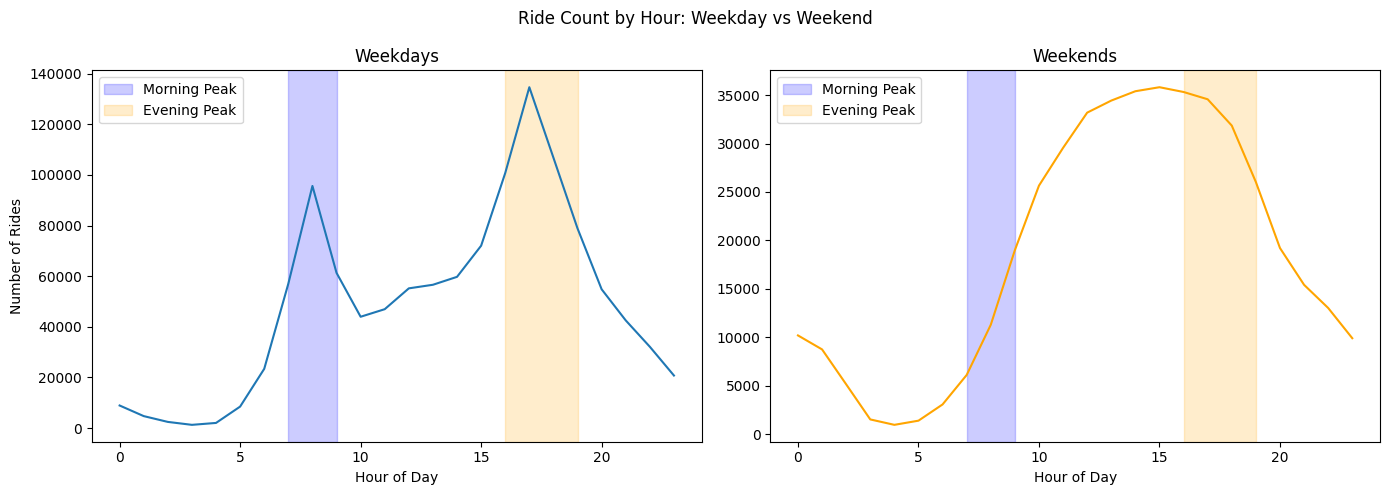

In [29]:
import matplotlib.pyplot as plt
weekdays = np.where(df_com['started_at'].dt.weekday < 5, 'Weekday', 'Weekend')
by_hour_type = df_com.groupby([weekdays, df_com['started_at'].dt.hour]).size()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
by_hour_type.loc['Weekday'].plot(ax=ax[0], title='Weekdays')
ax[0].axvspan(7, 9, alpha=0.2, color='blue', label='Morning Peak')
ax[0].axvspan(16, 19, alpha=0.2, color='orange', label='Evening Peak')
ax[0].set_xlabel('Hour of Day')
ax[0].set_ylabel('Number of Rides')
ax[0].legend()

by_hour_type.loc['Weekend'].plot(ax=ax[1], title='Weekends', color='orange')
ax[1].axvspan(7, 9, alpha=0.2, color='blue', label='Morning Peak')
ax[1].axvspan(16, 19, alpha=0.2, color='orange', label='Evening Peak')
ax[1].set_xlabel('Hour of Day')
ax[1].legend()

plt.suptitle('Ride Count by Hour: Weekday vs Weekend')
plt.tight_layout()
plt.show()

### because we investigate the morning and evening peak hours, so we only one weekdays

In [30]:
# check the morning and evening peak difference in all days
morning_rides = df_com[(df_com['hour'].between(7, 8)) & (df_com['day_of_week']<5)]
evening_rides = df_com[(df_com['hour'].between(16, 18)) & (df_com['day_of_week']<5)]

print(f"Morning Peak(all days): {len(morning_rides):,}")
print(f"Evening Peak(all days): {len(evening_rides):,}")

Morning Peak(all days): 152,661
Evening Peak(all days): 342,120


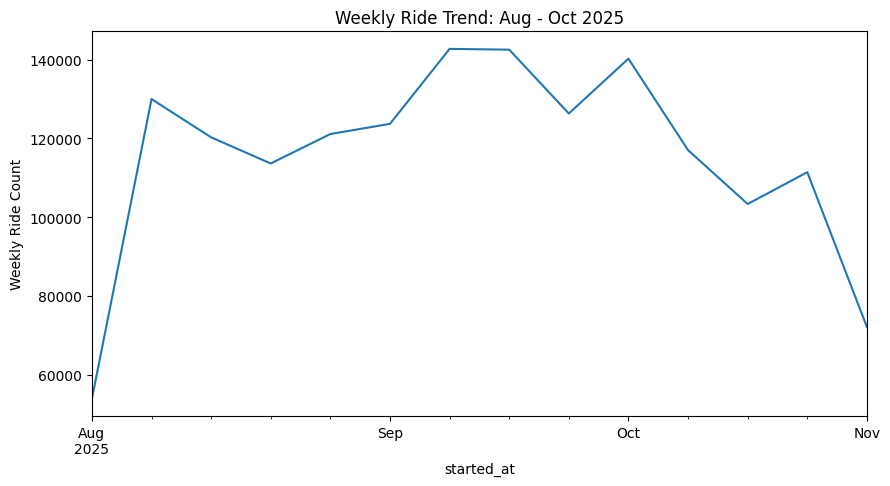

In [31]:
import matplotlib.pyplot as plt
df_com_ts = df_com.set_index('started_at')
weekly = df_com_ts.resample('W').size()
weekly.plot(figsize=(10, 5))
plt.ylabel('Weekly Ride Count')
plt.title('Weekly Ride Trend: Aug - Oct 2025')
plt.show()

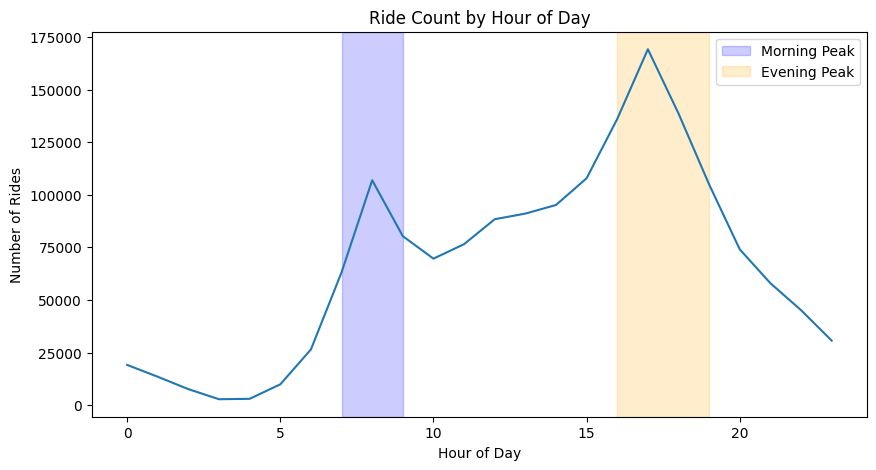

In [32]:
by_hour = df_com.groupby(df_com['started_at'].dt.hour).size()
by_hour.plot(figsize=(10, 5))
plt.xlabel('Hour of Day')
plt.ylabel('Number of Rides')
plt.title('Ride Count by Hour of Day')
plt.axvspan(7, 9, alpha=0.2, color='blue', label='Morning Peak')
plt.axvspan(16, 19, alpha=0.2, color='orange', label='Evening Peak')
plt.legend()
plt.show()

In [33]:
# calculate the departures and arrivals number in each station in the morning
morning_out = morning_rides.groupby('start_station_id').size().rename('departures')
morning_in = morning_rides.groupby('end_station_id').size().rename('arrivals')

In [34]:
morning_flow = pd.concat([morning_out, morning_in], axis=1)
print(morning_flow.isnull().sum()) # it is normal that some station does not have departure or arrival rides
morning_flow.fillna(0, inplace=True)
print(morning_flow.isnull().sum())

departures    2
arrivals      7
dtype: int64
departures    0
arrivals      0
dtype: int64


In [35]:
morning_flow['net_flow'] = morning_flow['arrivals'] - morning_flow['departures']
morning_flow.head(1)

,departures,arrivals,net_flow
A32000,197.0,791.0,594.0


In [36]:
# calculate the departures and arrivals number in each station in the morning
evening_dep = evening_rides.groupby('start_station_id').size().rename('departures')
evening_arr = evening_rides.groupby('end_station_id').size().rename('arrivals')
evening_flow = pd.concat([evening_dep, evening_arr], axis=1).fillna(0)
evening_flow['net_flow'] = evening_flow['arrivals'] - evening_flow['departures']
evening_flow.head(1)

,departures,arrivals,net_flow
A32000,943,576,-367


In [37]:
print(f"median for morning peak: {morning_flow['net_flow'].median():.1f}")
print(f"median for evening peak: {evening_flow['net_flow'].median():.1f}")

median for morning peak: -27.0
median for evening peak: 28.0


In [38]:
df_net_flow = morning_flow[['net_flow']].join(evening_flow[['net_flow']], lsuffix='_morning', rsuffix='_evening', how='outer').fillna(0)
total = len(df_net_flow)
df_net_flow.head(1)

,net_flow_morning,net_flow_evening
A32000,594.0,-367


In [39]:
# four commute patterns
early_out_late_in = ((df_net_flow['net_flow_morning'] < 0) & (df_net_flow['net_flow_evening'] > 0)).sum()
early_in_late_out = ((df_net_flow['net_flow_morning'] > 0) & (df_net_flow['net_flow_evening'] < 0)).sum()
both_negative     = ((df_net_flow['net_flow_morning'] < 0) & (df_net_flow['net_flow_evening'] < 0)).sum()
both_positive     = ((df_net_flow['net_flow_morning'] > 0) & (df_net_flow['net_flow_evening'] > 0)).sum()

print(f"\nMorning out and evening in : {early_out_late_in} ({early_out_late_in/total*100:.1f}%)")
print(f"Morning in  and evening out: {early_in_late_out} ({early_in_late_out/total*100:.1f}%)")
print(f"Both morning and evening out: {both_negative} ({both_negative/total*100:.1f}%)")
print(f"Both morning and evening in : {both_positive} ({both_positive/total*100:.1f}%)")
print(f"Total stations: {total}")



Morning out and evening in : 324 (55.6%)
Morning in  and evening out: 168 (28.8%)
Both morning and evening out: 42 (7.2%)
Both morning and evening in : 39 (6.7%)
Total stations: 583


In [40]:
# merge station info into df_net_flow for later use
df_net_flow = df_net_flow.merge(stations[['Number', 'NAME', 'Municipality']], left_index=True, right_on='Number', how='left').set_index('Number')

df_net_flow.head(3)

,net_flow_morning,net_flow_evening,NAME,Municipality
Number,,,,
A32000,594.0,-367,Fan Pier,Boston
A32001,-317.0,289,Union Square - Brighton Ave at Cambridge St,Boston
A32002,-80.0,349,Commonwealth Ave at Agganis Way,Boston


In [41]:
df_net_flow['reversal'] = df_net_flow['net_flow_evening'] - df_net_flow['net_flow_morning']

df_reversal_top10 = df_net_flow.sort_values('reversal', ascending=False).head(10)
print(df_reversal_top10[['NAME', 'Municipality', 'net_flow_morning', 'net_flow_evening', 'reversal']].to_string(index=False))

                                              NAME Municipality  net_flow_morning  net_flow_evening  reversal
                                     MIT Vassar St    Cambridge           -2176.0              1302    3478.0
                 Nashua Street at Red Auerbach Way       Boston            -897.0              1153    2050.0
     Nashua Street at Red Auerbach Way [Extension]       Boston            -854.0              1013    1867.0
                   Inman Square at Springfield St.    Cambridge            -821.0               981    1802.0
                                W Broadway at D St       Boston            -873.0               779    1652.0
           Sennott Park Broadway at Norfolk Street    Cambridge            -686.0               603    1289.0
Cambridge Dept. of Public Works -147 Hampshire St.    Cambridge            -653.0               627    1280.0
                                         Dana Park    Cambridge            -793.0               480    1273.0
          

### The stations with the biggest reversal from morning to evening show a dramatic shift in flow direction. For example, station M32042（ MIT Vassar St）in cambridge has a morning net flow of -2417 and an evening net flow of +1593, a reversal of 4010 — strongly confirming the commuting pattern.

In [42]:
from scipy import stats


paired = df_net_flow.dropna(subset=['net_flow_morning', 'net_flow_evening'])

stat, p = stats.wilcoxon(paired['net_flow_morning'], paired['net_flow_evening'])
print(f"Wilcoxon signed-rank test:")
print(f"  statistic = {stat:.2f}")
print(f"  p-value = {p:.2e}")
if p < 0.05:
    print("  → Statistically significant difference (p < 0.05)")

Wilcoxon signed-rank test:
  statistic = 65180.50
  p-value = 2.34e-06
  → Statistically significant difference (p < 0.05)


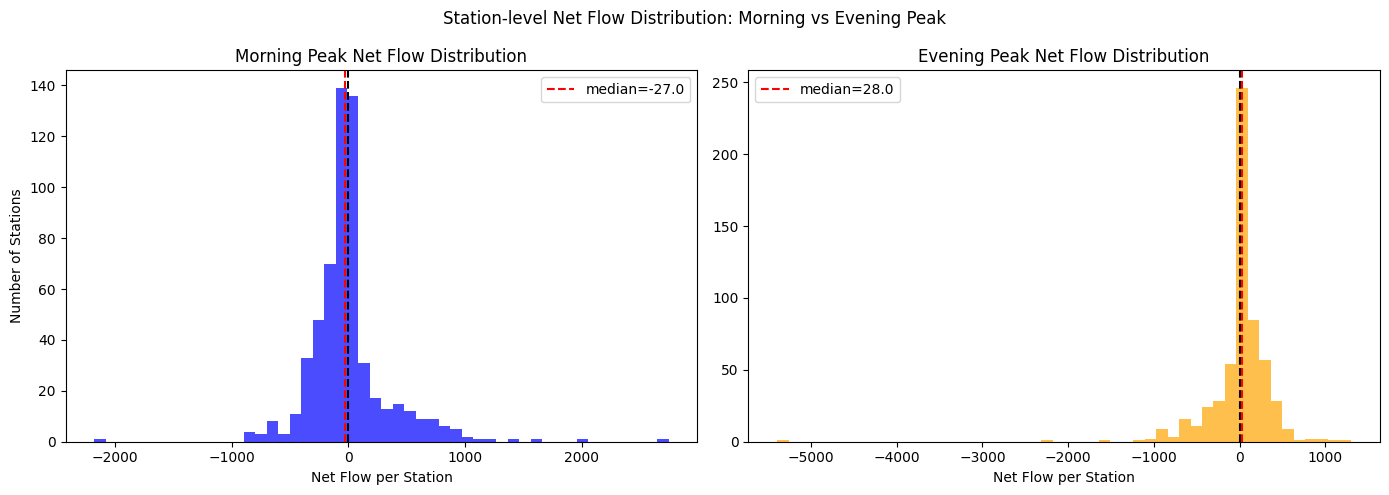

In [43]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].hist(morning_flow['net_flow'], bins=50, color='blue', alpha=0.7)
ax[0].axvline(x=0, color='black', linestyle='--')
ax[0].axvline(x=morning_flow['net_flow'].median(), color='red', linestyle='--', label=f"median={morning_flow['net_flow'].median():.1f}")
ax[0].set_title('Morning Peak Net Flow Distribution')
ax[0].set_xlabel('Net Flow per Station')
ax[0].set_ylabel('Number of Stations')
ax[0].legend()

ax[1].hist(evening_flow['net_flow'], bins=50, color='orange', alpha=0.7)
ax[1].axvline(x=0, color='black', linestyle='--')
ax[1].axvline(x=evening_flow['net_flow'].median(), color='red', linestyle='--', label=f"median={evening_flow['net_flow'].median():.1f}")
ax[1].set_title('Evening Peak Net Flow Distribution')
ax[1].set_xlabel('Net Flow per Station')
ax[1].legend()

plt.suptitle('Station-level Net Flow Distribution: Morning vs Evening Peak')
plt.tight_layout()
plt.show()

### From the above graph, we can see that in the morning peak the net flow distribution histograph is left skewed. That means more stations have bikes outflow. In evening peak, net flow distribution histograph is right skewed. That means more station are receiving the blue bikes

### Answer to Q1


### There is a significant difference in station-level bike storage behavior between morning peak and evening peak
The Wilcoxon signed-rank test confirms the difference is statistically significant (p = 4.72e-06, p << 0.05).

On weekdays, there is a clear double-peak pattern with strong morning outflow and evening inflow. On weekends, this pattern disappears as shown in the above graph. It confirmed that the morning and evening has peak and the main reason for this difference is commute and the difference is statistically significant.

For all stations data From the above graph, we can see that in the morning peak the net flow distribution histograph is left skewed. That means more stations have bikes outflow. 
in evening peak, net flow distribution histograph is right skewed. That means more station are receiving the blue bikes.

1.From the median value: the median values in morning is negative, whichshows more bikes out than in. the median is positive in pm, which shows more bikes in than out

2.From the commute pattern: it turns out for most stations(55.1%), in Morning peak, the bike departs. In Evening peak, the bike arrives

3.From the Station-level Reversal, The stations with the biggest reversal from morning to evening show a dramatic shift in flow direction. For example, station M32042（ MIT Vassar St）in cambridge has a morning net flow of -2417 and an evening net flow of +1593, a reversal of 4010 — strongly confirming the commuting pattern.

## For Boston-area stations

In [44]:
df_net_flow_boston = df_net_flow[df_net_flow['Municipality'] == 'Boston']
df_net_flow_boston

,net_flow_morning,net_flow_evening,NAME,Municipality,reversal
Number,,,,,
A32000,594.0,-367,Fan Pier,Boston,-961.0
A32001,-317.0,289,Union Square - Brighton Ave at Cambridge St,Boston,606.0
A32002,-80.0,349,Commonwealth Ave at Agganis Way,Boston,429.0
A32003,404.0,-120,B.U. Central T Stop - 725 Commonwealth Ave,Boston,-524.0
A32004,2022.0,-2270,Longwood Ave at Binney St,Boston,-4292.0
...,...,...,...,...,...
E32016,-229.0,242,Commonwealth Ave at Naples Rd,Boston,471.0
E32017,1.0,6,Butler T Stop,Boston,5.0
E32018,2.0,-26,Truman Parkway at Fairmount Ave,Boston,-28.0


In [45]:
total_boston = df_net_flow_boston.shape[0]

In [46]:
# median
print(f"[Boston] median for morning peak: {df_net_flow_boston['net_flow_morning'].median():.1f}")
print(f"[Boston] median for evening peak: {df_net_flow_boston['net_flow_evening'].median():.1f}")

# four commute patterns
early_out_late_in = ((df_net_flow_boston['net_flow_morning'] < 0) & (df_net_flow_boston['net_flow_evening'] > 0)).sum()
early_in_late_out = ((df_net_flow_boston['net_flow_morning'] > 0) & (df_net_flow_boston['net_flow_evening'] < 0)).sum()
both_negative     = ((df_net_flow_boston['net_flow_morning'] < 0) & (df_net_flow_boston['net_flow_evening'] < 0)).sum()
both_positive     = ((df_net_flow_boston['net_flow_morning'] > 0) & (df_net_flow_boston['net_flow_evening'] > 0)).sum()

print(f"\n[Boston] Morning out and evening in : {early_out_late_in} ({early_out_late_in/total_boston*100:.1f}%)")
print(f"[Boston] Morning in  and evening out: {early_in_late_out} ({early_in_late_out/total_boston*100:.1f}%)")
print(f"[Boston] Both morning and evening out: {both_negative} ({both_negative/total_boston*100:.1f}%)")
print(f"[Boston] Both morning and evening in : {both_positive} ({both_positive/total_boston*100:.1f}%)")
print(f"[Boston] Total stations: {total_boston}")

# top 10 reversal
print("\n[Boston] Stations with biggest reversal (morning to evening):")
print(df_net_flow_boston.sort_values('reversal', ascending=False)[['NAME', 'net_flow_morning', 'net_flow_evening', 'reversal']].head(10).to_string(index=False))

[Boston] median for morning peak: -29.0
[Boston] median for evening peak: 26.5

[Boston] Morning out and evening in : 186 (55.0%)
[Boston] Morning in  and evening out: 101 (29.9%)
[Boston] Both morning and evening out: 25 (7.4%)
[Boston] Both morning and evening in : 19 (5.6%)
[Boston] Total stations: 338

[Boston] Stations with biggest reversal (morning to evening):
                                         NAME  net_flow_morning  net_flow_evening  reversal
            Nashua Street at Red Auerbach Way            -897.0              1153    2050.0
Nashua Street at Red Auerbach Way [Extension]            -854.0              1013    1867.0
                           W Broadway at D St            -873.0               779    1652.0
                  Valenti Way at Haverhill St            -437.0               822    1259.0
                  Lewis Wharf at Atlantic Ave            -660.0               460    1120.0
                      Canal St at Causeway St            -581.0               

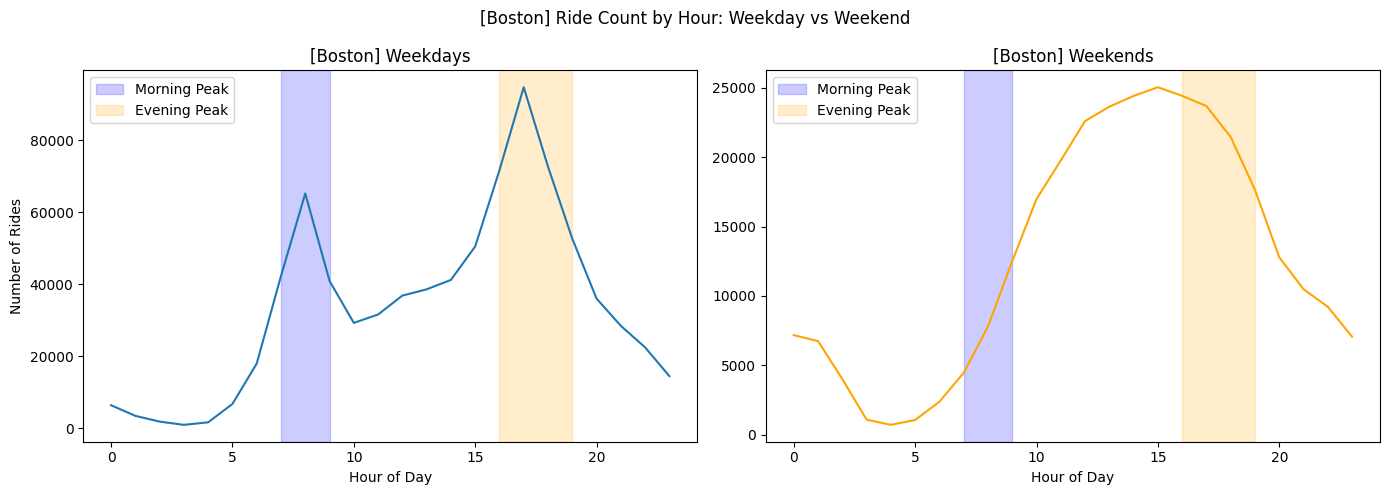

In [47]:
boston_rides = df_com[
    (df_com['start_municipality'] == 'Boston') | 
    (df_com['end_municipality'] == 'Boston')
]

weekdays_boston = np.where(boston_rides['started_at'].dt.weekday < 5, 'Weekday', 'Weekend')
by_hour_boston = boston_rides.groupby([weekdays_boston, boston_rides['started_at'].dt.hour]).size()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

by_hour_boston.loc['Weekday'].plot(ax=ax[0], title='[Boston] Weekdays')
ax[0].axvspan(7, 9, alpha=0.2, color='blue', label='Morning Peak')
ax[0].axvspan(16, 19, alpha=0.2, color='orange', label='Evening Peak')
ax[0].set_xlabel('Hour of Day')
ax[0].set_ylabel('Number of Rides')
ax[0].legend()

by_hour_boston.loc['Weekend'].plot(ax=ax[1], title='[Boston] Weekends', color='orange')
ax[1].axvspan(7, 9, alpha=0.2, color='blue', label='Morning Peak')
ax[1].axvspan(16, 19, alpha=0.2, color='orange', label='Evening Peak')
ax[1].set_xlabel('Hour of Day')
ax[1].legend()

plt.suptitle('[Boston] Ride Count by Hour: Weekday vs Weekend')
plt.tight_layout()
plt.show()

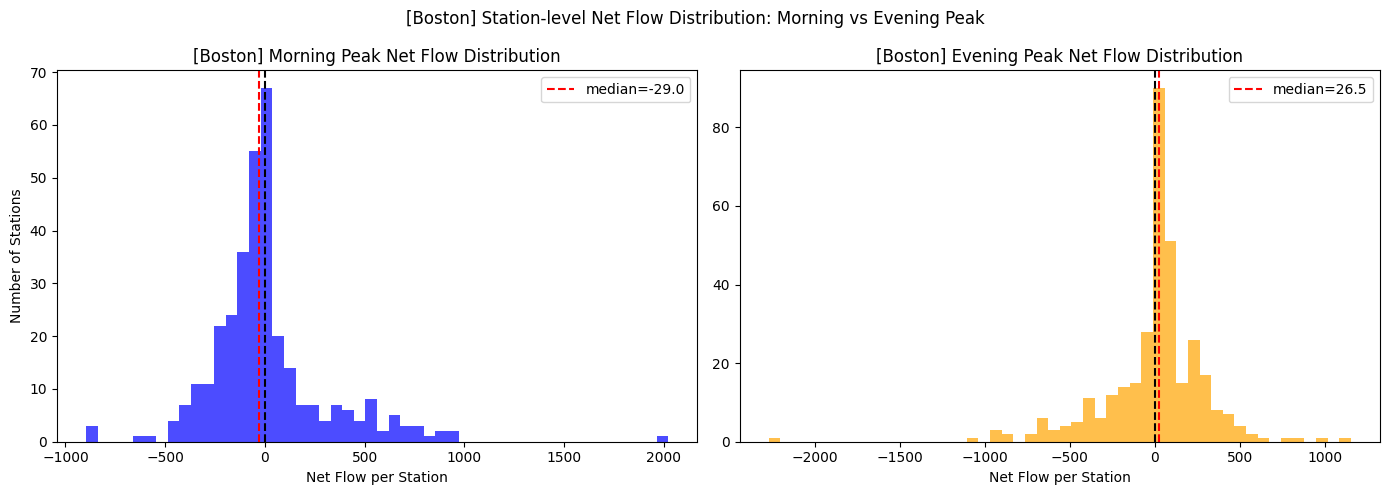

In [48]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].hist(df_net_flow_boston['net_flow_morning'], bins=50, color='blue', alpha=0.7)
ax[0].axvline(x=0, color='black', linestyle='--')
ax[0].axvline(x=df_net_flow_boston['net_flow_morning'].median(), color='red', linestyle='--',
              label=f"median={df_net_flow_boston['net_flow_morning'].median():.1f}")
ax[0].set_title('[Boston] Morning Peak Net Flow Distribution')
ax[0].set_xlabel('Net Flow per Station')
ax[0].set_ylabel('Number of Stations')
ax[0].legend()

ax[1].hist(df_net_flow_boston['net_flow_evening'], bins=50, color='orange', alpha=0.7)
ax[1].axvline(x=0, color='black', linestyle='--')
ax[1].axvline(x=df_net_flow_boston['net_flow_evening'].median(), color='red', linestyle='--',
              label=f"median={df_net_flow_boston['net_flow_evening'].median():.1f}")
ax[1].set_title('[Boston] Evening Peak Net Flow Distribution')
ax[1].set_xlabel('Net Flow per Station')
ax[1].legend()

plt.suptitle('[Boston] Station-level Net Flow Distribution: Morning vs Evening Peak')
plt.tight_layout()
plt.show()

### Answer to Q1

### There is a significant difference in station-level bike storage behavior between morning peak and evening peak

After analyzing all Bluebikes stations system-wide, we zoom into Boston-area stations for a deeper analysis.
From the histogram, the distribution range is noticeably narrower than the global view, indicating that extreme flow values are absent in Boston — stations here have more moderate and concentrated flow levels, without the outliers seen at Cambridge's university stations.
The overall pattern is consistent with the global trend: morning peak is left-skewed (median = -27) and evening peak is right-skewed (median = +19.5), confirming that bikes flow out in the morning and return in the evening.
However, two notable differences emerge:

Morning median (-27) is more negative than the global median (-24), meaning Boston stations experience stronger outflow in the morning
Evening median (+19.5) is lower than the global median (+26), meaning fewer bikes return to Boston in the evening

This pattern aligns well with Boston situation, where a significant amount of land is dedicated to commercial, industrial, and institutional uses rather than residential areas. Additionally, Boston is home to major transit hubs such as South Station, North Station, and Back Bay Station.
Many commuters arrive by subway or commuter rail, then use Bluebikes as a last-mile connector to reach their final destination — explaining the strong morning outflow. In the evening, riders return to these transit hubs and take public transit home rather than cycling back, resulting in weaker return flow at Boston stations.

### 2. Empty-Station Risk
  - Which stations are more likely to become “empty” during the morning peak?
  - Interpret “empty” as a station likely to experience a shortage of available bikes.

In [49]:
empty_risk = df_net_flow.merge(stations[['Number', 'Total Docks']], left_index=True, right_on='Number', how='left').set_index('Number')

In [50]:
# calculate flow ratio
empty_risk['flow_ratio'] = empty_risk['net_flow_morning'] / empty_risk['Total Docks']
empty_risk = empty_risk.sort_values('flow_ratio', ascending=True)

# Top 10
print("All stations Top 10 Empty Risk Stations (Morning Peak):")
print(empty_risk[['NAME', 'Municipality', 'Total Docks', 'net_flow_morning', 'flow_ratio']].head(10).to_string(index=False))

All stations Top 10 Empty Risk Stations (Morning Peak):
                                                          NAME Municipality  Total Docks  net_flow_morning  flow_ratio
                                  Old Morse Park at Putnam Ave    Cambridge           15            -638.0  -42.533333
                                                     Dana Park    Cambridge           19            -793.0  -41.736842
                                                 MIT Vassar St    Cambridge           53           -2176.0  -41.056604
                       Kennedy-Longfellow School 158 Spring St    Cambridge           19            -772.0  -40.631579
                                            W Broadway at D St       Boston           23            -873.0  -37.956522
Harvard University Housing - 115 Putnam Ave at Peabody Terrace    Cambridge           15            -551.0  -36.733333
                       Sennott Park Broadway at Norfolk Street    Cambridge           19            -686.0  -36

## for only boston stations

In [51]:
# Boston Only Top 10
print("\nBoston Top 10 Empty Risk Stations (Morning Peak):")
print(empty_risk[empty_risk['Municipality'] == 'Boston'][['NAME', 'Total Docks', 'net_flow_morning', 'flow_ratio']].head(10).to_string(index=False))


Boston Top 10 Empty Risk Stations (Morning Peak):
                                         NAME  Total Docks  net_flow_morning  flow_ratio
                           W Broadway at D St           23            -873.0  -37.956522
South End Library - Tremont St at W Newton St           15            -434.0  -28.933333
                Commonwealth Ave at Griggs St           15            -413.0  -27.533333
Nashua Street at Red Auerbach Way [Extension]           32            -854.0  -26.687500
                   Harvard Ave at Brainerd Rd           15            -396.0  -26.400000
                  W Broadway at Dorchester St           17            -447.0  -26.294118
                      Canal St at Causeway St           23            -581.0  -25.260870
             Walbridge St at Commonwealth Ave           19            -477.0  -25.105263
                Commonwealth Ave at Kelton St           15            -375.0  -25.000000
        South Boston Library - 646 E Broadway           15 

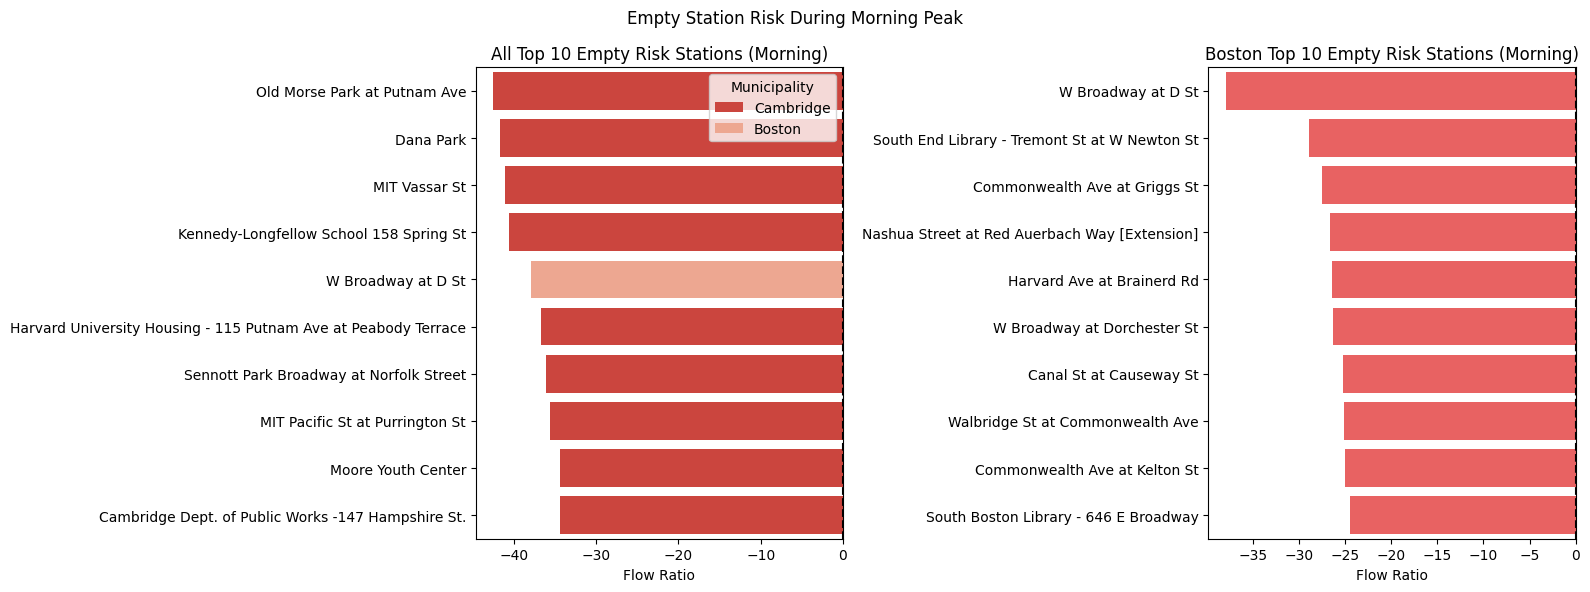

In [52]:
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Global Top 10
top10_empty = empty_risk.head(10)
sns.barplot(data=top10_empty, x='flow_ratio', y='NAME', 
            hue='Municipality', ax=axes[0], palette='Reds_r')
axes[0].axvline(x=0, color='black', linestyle='--')
axes[0].set_title('All Top 10 Empty Risk Stations (Morning)')
axes[0].set_xlabel('Flow Ratio')
axes[0].set_ylabel('')

# Boston Only Top 10
top10_empty_boston = empty_risk[empty_risk['Municipality'] == 'Boston'].head(10)
sns.barplot(data=top10_empty_boston, x='flow_ratio', y='NAME',
            color='red', alpha=0.7, ax=axes[1])
axes[1].axvline(x=0, color='black', linestyle='--')
axes[1].set_title('Boston Top 10 Empty Risk Stations (Morning)')
axes[1].set_xlabel('Flow Ratio')
axes[1].set_ylabel('')

plt.suptitle('Empty Station Risk During Morning Peak')
plt.tight_layout()
plt.show()

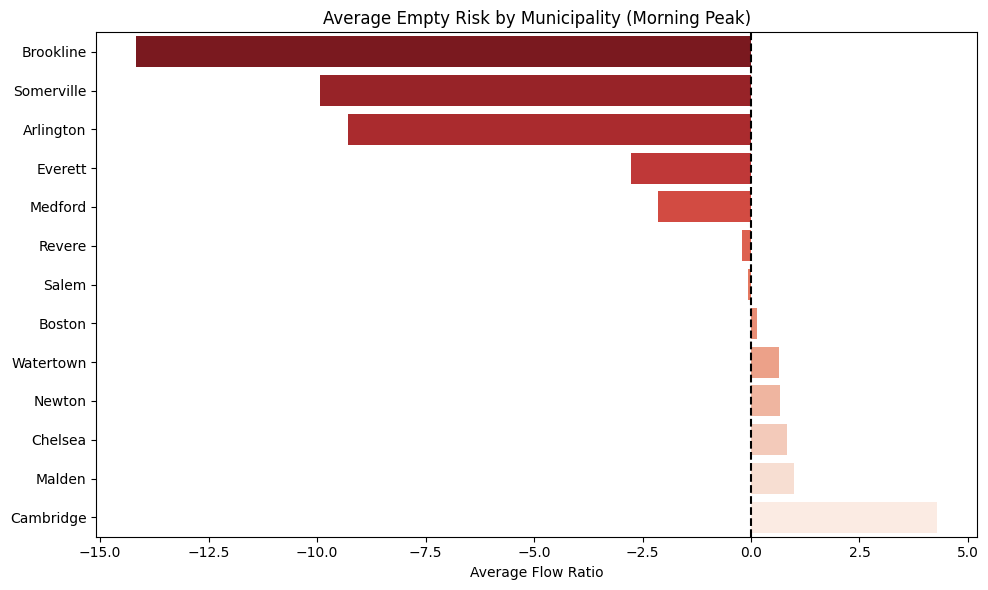

In [53]:
empty_by_muni = empty_risk.groupby('Municipality')['flow_ratio'].mean().sort_values().reset_index()
empty_by_muni.columns = ['Municipality', 'avg_flow_ratio']

plt.figure(figsize=(10, 6))
sns.barplot(data=empty_by_muni, x='avg_flow_ratio', y='Municipality', 
            palette='Reds_r', hue='Municipality', legend=False)
plt.axvline(x=0, color='black', linestyle='--')
plt.title('Average Empty Risk by Municipality (Morning Peak)')
plt.xlabel('Average Flow Ratio')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [54]:
morning_weekday = df_com[
    (df_com['day_of_week'] < 5) &
    (df_com['started_at'].dt.hour.between(7, 8))
]

morning_weekend = df_com[
    (df_com['day_of_week'] >= 5) &
    (df_com['started_at'].dt.hour.between(7, 8))
]

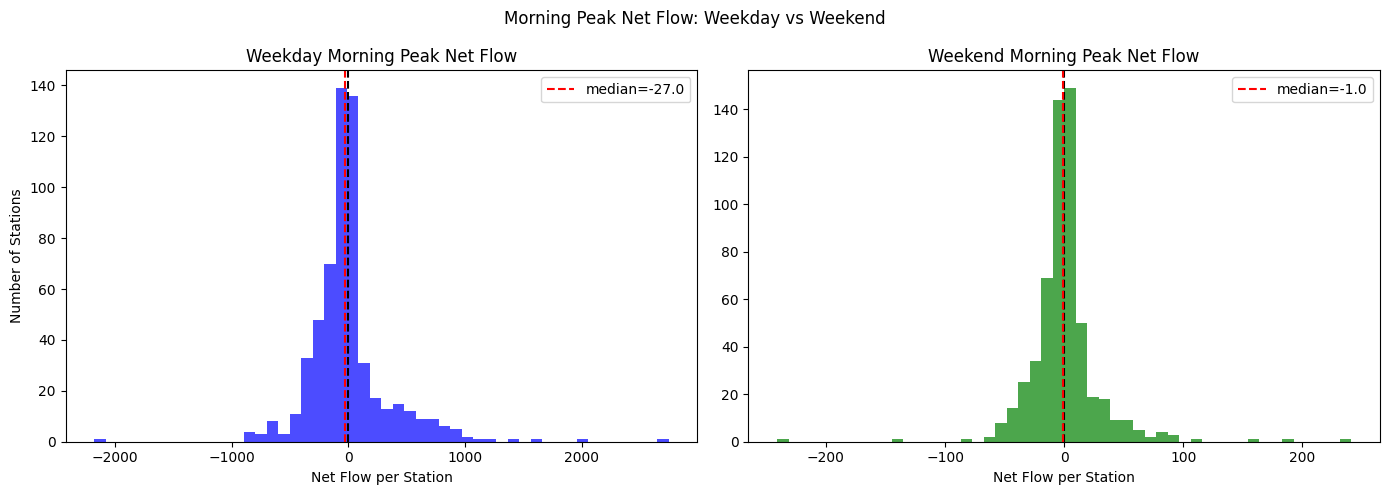

In [55]:
# calculate net flow for weekday and weekend morning peak
# weekday
morning_weekday_out = morning_weekday.groupby('start_station_id').size().rename('departures')
morning_weekday_in = morning_weekday.groupby('end_station_id').size().rename('arrivals')
morning_flow_weekday = pd.concat([morning_weekday_out, morning_weekday_in], axis=1).fillna(0)
morning_flow_weekday['net_flow'] = morning_flow_weekday['arrivals'] - morning_flow_weekday['departures']

# weekend
morning_weekend_out = morning_weekend.groupby('start_station_id').size().rename('departures')
morning_weekend_in = morning_weekend.groupby('end_station_id').size().rename('arrivals')
morning_flow_weekend = pd.concat([morning_weekend_out, morning_weekend_in], axis=1).fillna(0)
morning_flow_weekend['net_flow'] = morning_flow_weekend['arrivals'] - morning_flow_weekend['departures']

# plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(morning_flow_weekday['net_flow'], bins=50, color='blue', alpha=0.7)
axes[0].axvline(x=0, color='black', linestyle='--')
axes[0].axvline(x=morning_flow_weekday['net_flow'].median(), color='red', linestyle='--',
                label=f"median={morning_flow_weekday['net_flow'].median():.1f}")
axes[0].set_title('Weekday Morning Peak Net Flow')
axes[0].set_xlabel('Net Flow per Station')
axes[0].set_ylabel('Number of Stations')
axes[0].legend()

axes[1].hist(morning_flow_weekend['net_flow'], bins=50, color='green', alpha=0.7)
axes[1].axvline(x=0, color='black', linestyle='--')
axes[1].axvline(x=morning_flow_weekend['net_flow'].median(), color='red', linestyle='--',
                label=f"median={morning_flow_weekend['net_flow'].median():.1f}")
axes[1].set_title('Weekend Morning Peak Net Flow')
axes[1].set_xlabel('Net Flow per Station')
axes[1].legend()

plt.suptitle('Morning Peak Net Flow: Weekday vs Weekend')
plt.tight_layout()
plt.show()

## Answer to Q2




In [56]:
print('For all areas')
print()
print('The top 10 highest empty risk stations are mostly located near MIT and Harvard in Cambridge area. Because the MIT and Harvard campuses are big and parking is very difficult there. Students may often need to ride to the classes.During morning peak, large numbers of students and staff ride bikes to campus, causing bikes in a loss of supply rapidly. More details are listed as below')
print('')
print("Top 10 highest empty risk stations during morning peak:\n")
print(empty_risk[['NAME', 'Municipality', 'Total Docks', 'net_flow_morning', 'flow_ratio']].head(10).to_string(index=False))

For all areas

The top 10 highest empty risk stations are mostly located near MIT and Harvard in Cambridge area. Because the MIT and Harvard campuses are big and parking is very difficult there. Students may often need to ride to the classes.During morning peak, large numbers of students and staff ride bikes to campus, causing bikes in a loss of supply rapidly. More details are listed as below

Top 10 highest empty risk stations during morning peak:

                                                          NAME Municipality  Total Docks  net_flow_morning  flow_ratio
                                  Old Morse Park at Putnam Ave    Cambridge           15            -638.0  -42.533333
                                                     Dana Park    Cambridge           19            -793.0  -41.736842
                                                 MIT Vassar St    Cambridge           53           -2176.0  -41.056604
                       Kennedy-Longfellow School 158 Spring St    Cam

The above stations, apart from one station in boston, are all in cambridge area. Most of stations are near MIT harvard or other residential area. That totally makes sense since many MIT harvard students need to ride to the campus during the morning time. 
However overally, the empty station risk in the cambridge area is not high. It is partly because in cambridge area, there are also many big companies like microsoft, Google. Many people ride in, which offset the bikes outflow. 

Compared with cambridge, the other areas such as the brookline, somerville and arlington, the empty risk is higher. The reasons should be many people live in these areas and need to ride to work on weekdays. To make things worse, the number of the docks in these areas is not very big.

Finally, from the above comparision graph between weekdays and weekends, we can also get an idea that the empty risk is caused by the commute. 


In [57]:
print('For Boston Area')

print('The top 10 highest empty risk stations are mostly located near south end/south boston and allston/brighton area. During morning peak, large numbers of students and risidents ride bikes to campus or companies, causing bikes in a loss of supply rapidly. More details are listed as below')
print("\nBoston Top 10 Empty Risk Stations (Morning Peak):")
print(empty_risk[empty_risk['Municipality'] == 'Boston'][['NAME', 'Total Docks', 'net_flow_morning', 'flow_ratio']].head(10).to_string(index=False))

For Boston Area
The top 10 highest empty risk stations are mostly located near south end/south boston and allston/brighton area. During morning peak, large numbers of students and risidents ride bikes to campus or companies, causing bikes in a loss of supply rapidly. More details are listed as below

Boston Top 10 Empty Risk Stations (Morning Peak):
                                         NAME  Total Docks  net_flow_morning  flow_ratio
                           W Broadway at D St           23            -873.0  -37.956522
South End Library - Tremont St at W Newton St           15            -434.0  -28.933333
                Commonwealth Ave at Griggs St           15            -413.0  -27.533333
Nashua Street at Red Auerbach Way [Extension]           32            -854.0  -26.687500
                   Harvard Ave at Brainerd Rd           15            -396.0  -26.400000
                  W Broadway at Dorchester St           17            -447.0  -26.294118
                      Can

Boston's empty station risk is much less severious than Cambridge's area. They followed the similar patterns to cambridge that the high empty risk are accumulated in the South end residential and Allston/Brighton area near Bu. However, the consistently small dock capacity with most dock being 15 across Boston's high empty risk stations suggests that the outflow can quickly lead to bike shortages. These stations may need attention for manually refilling the bikes.

### 3. Full-Station Risk
  - Which stations are more likely to become “full” during the evening peak?
  - Interpret “full” as a station likely to experience a shortage of available docks.

Global Top 10 Full Risk Stations (Evening Peak):

1. Inman Square at Springfield St. (Cambridge) - flow_ratio = 39.2
2. Valenti Way at Haverhill St (Boston) - flow_ratio = 34.2
3. W Broadway at D St (Boston) - flow_ratio = 33.9
4. Cambridge Dept. of Public Works -147 Hampshire St. (Cambridge) - flow_ratio = 33.0
5. Sennott Park Broadway at Norfolk Street (Cambridge) - flow_ratio = 31.7
6. Nashua Street at Red Auerbach Way [Extension] (Boston) - flow_ratio = 31.7
7. Nashua Street at Red Auerbach Way (Boston) - flow_ratio = 31.2
8. Union Square - Somerville (Somerville) - flow_ratio = 30.9
9. Edgerly Education Center (Somerville) - flow_ratio = 30.3
10. W Broadway at Dorchester St (Boston) - flow_ratio = 30.0


                                              NAME Municipality  Total Docks  net_flow_evening  flow_ratio
                   Inman Square at Springfield St.    Cambridge           25               981   39.240000
                       Valenti Way at Haverhill St       Boston    

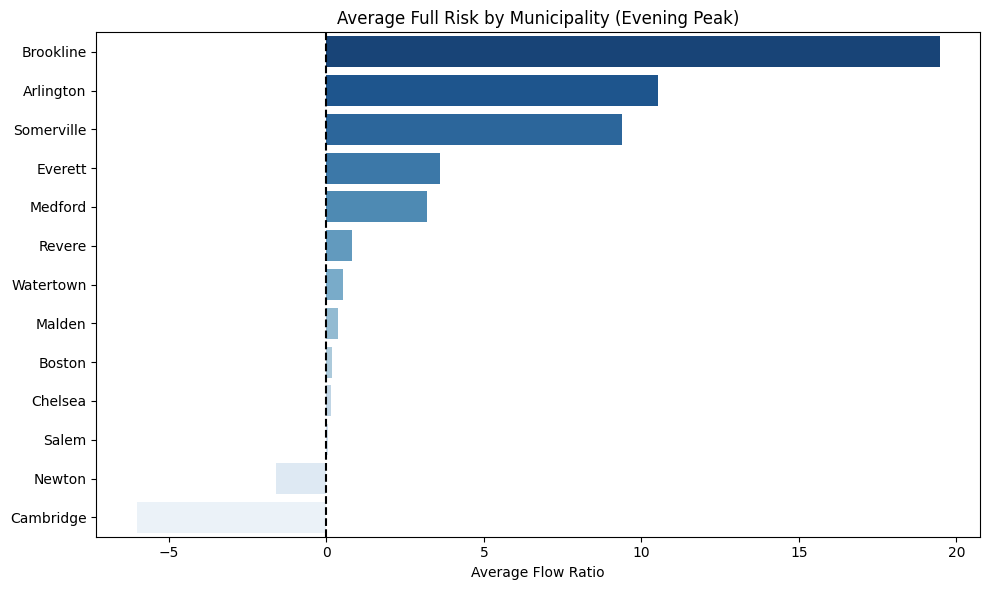

In [58]:
# Q3 Full Station Risk - Evening Peak

# calculate full risk from df_net_flow
full_risk = df_net_flow.merge(
    stations[['Number', 'Total Docks']],
    left_index=True,
    right_on='Number',
    how='left'
).set_index('Number')

# flow_ratio for full risk (most positive = highest full risk)
full_risk['flow_ratio'] = full_risk['net_flow_evening'] / full_risk['Total Docks']
full_risk = full_risk.sort_values('flow_ratio', ascending=False)

# All areas Top 10
print("Global Top 10 Full Risk Stations (Evening Peak):\n")
for i, row in enumerate(full_risk.head(10).itertuples(), 1):
    print(f"{i}. {row.NAME} ({row.Municipality}) - flow_ratio = {row.flow_ratio:.1f}")

print("\n")
print(full_risk[['NAME', 'Municipality', 'Total Docks', 'net_flow_evening', 'flow_ratio']].head(10).to_string(index=False))

# Boston Only Top 10
print("\nBoston Top 10 Full Risk Stations (Evening Peak):\n")
for i, row in enumerate(full_risk[full_risk['Municipality'] == 'Boston'].head(10).itertuples(), 1):
    print(f"{i}. {row.NAME} - flow_ratio = {row.flow_ratio:.1f}")

print("\n")
print(full_risk[full_risk['Municipality'] == 'Boston'][
    ['NAME', 'Total Docks', 'net_flow_evening', 'flow_ratio']
].head(10).to_string(index=False))

# Municipality level
full_by_muni = full_risk.groupby('Municipality')['flow_ratio'].mean().sort_values(ascending=False).reset_index()
full_by_muni.columns = ['Municipality', 'avg_flow_ratio']

plt.figure(figsize=(10, 6))
sns.barplot(data=full_by_muni, x='avg_flow_ratio', y='Municipality',
            hue='Municipality', palette='Blues_r', legend=False)
plt.axvline(x=0, color='black', linestyle='--')
plt.title('Average Full Risk by Municipality (Evening Peak)')
plt.xlabel('Average Flow Ratio')
plt.ylabel('')
plt.tight_layout()
plt.show()

### station that suffer from empty risk and full risk both risks

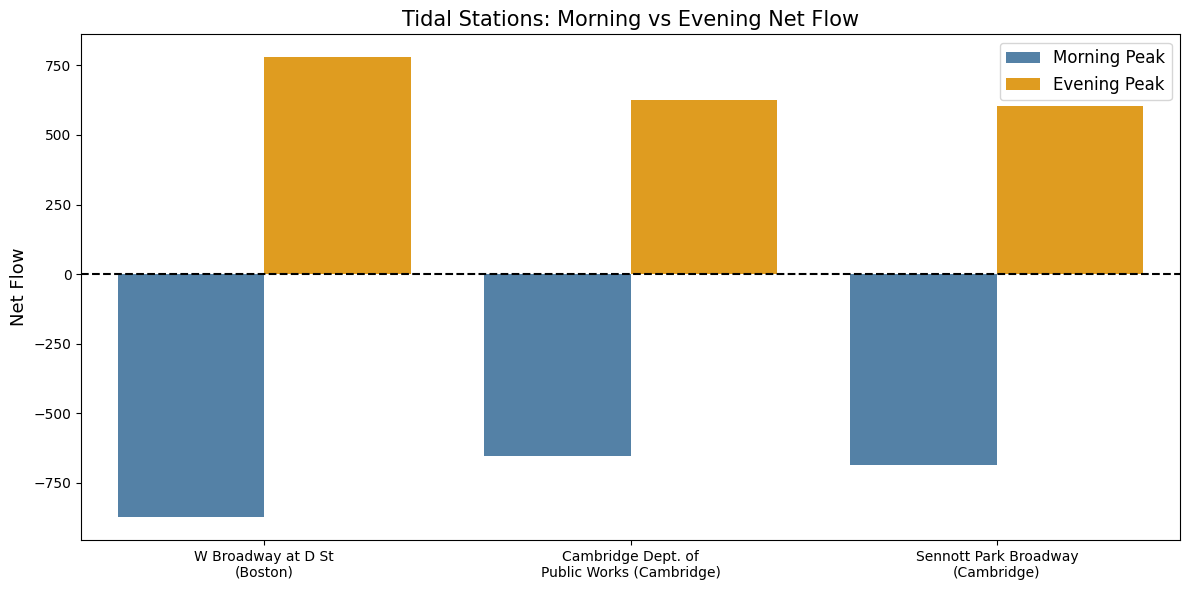

In [59]:
# All area tidal stations - appear in both Q2 and Q3 top 10
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

tidal_stations = ['W Broadway at D St', 
                  'Sennott Park Broadway at Norfolk Street',
                  'Cambridge Dept. of Public Works -147 Hampshire St.']

tidal_data = df_net_flow[df_net_flow['NAME'].isin(tidal_stations)][
    ['NAME', 'net_flow_morning', 'net_flow_evening']
]

# reshape to long format for seaborn
tidal_long = tidal_data.melt(
    id_vars='NAME',
    value_vars=['net_flow_morning', 'net_flow_evening'],
    var_name='Peak',
    value_name='Net Flow'
)
tidal_long['Peak'] = tidal_long['Peak'].map({
    'net_flow_morning': 'Morning Peak',
    'net_flow_evening': 'Evening Peak'
})

# shorten names
tidal_long['NAME'] = tidal_long['NAME'].map({
    'W Broadway at D St': 'W Broadway at D St\n(Boston)',
    'Sennott Park Broadway at Norfolk Street': 'Sennott Park Broadway\n(Cambridge)',
    'Cambridge Dept. of Public Works -147 Hampshire St.': 'Cambridge Dept. of\nPublic Works (Cambridge)'
})

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=tidal_long, x='NAME', y='Net Flow', 
            hue='Peak', palette=['steelblue', 'orange'],
            ax=ax)
ax.axhline(y=0, color='black', linestyle='--')
ax.set_title('Tidal Stations: Morning vs Evening Net Flow', fontsize=15)
ax.set_xlabel('')
ax.set_ylabel('Net Flow', fontsize=13)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

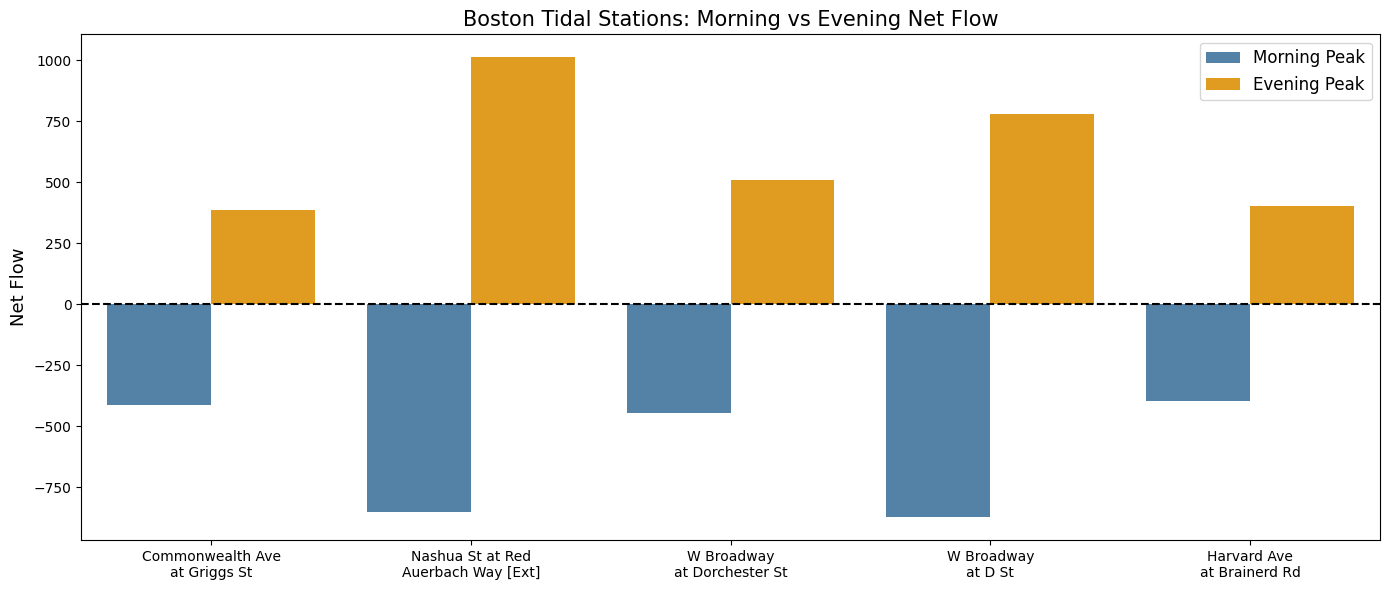

In [60]:
# Boston tidal stations - appear in both Q2 and Q3 Boston top 10
boston_tidal_stations = [
    'W Broadway at D St',
    'W Broadway at Dorchester St', 
    'Commonwealth Ave at Griggs St',
    'Harvard Ave at Brainerd Rd',
    'Nashua Street at Red Auerbach Way [Extension]'
]

boston_tidal_data = df_net_flow[df_net_flow['NAME'].isin(boston_tidal_stations)][
    ['NAME', 'net_flow_morning', 'net_flow_evening']
]

# reshape to long format
boston_tidal_long = boston_tidal_data.melt(
    id_vars='NAME',
    value_vars=['net_flow_morning', 'net_flow_evening'],
    var_name='Peak',
    value_name='Net Flow'
)
boston_tidal_long['Peak'] = boston_tidal_long['Peak'].map({
    'net_flow_morning': 'Morning Peak',
    'net_flow_evening': 'Evening Peak'
})

# shorten names
name_map = {
    'W Broadway at D St': 'W Broadway\nat D St',
    'W Broadway at Dorchester St': 'W Broadway\nat Dorchester St',
    'Commonwealth Ave at Griggs St': 'Commonwealth Ave\nat Griggs St',
    'Harvard Ave at Brainerd Rd': 'Harvard Ave\nat Brainerd Rd',
    'Nashua Street at Red Auerbach Way [Extension]': 'Nashua St at Red\nAuerbach Way [Ext]'
}
boston_tidal_long['NAME'] = boston_tidal_long['NAME'].map(name_map)

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=boston_tidal_long, x='NAME', y='Net Flow',
            hue='Peak', palette=['steelblue', 'orange'], ax=ax)
ax.axhline(y=0, color='black', linestyle='--')
ax.set_title('Boston Tidal Stations: Morning vs Evening Net Flow', fontsize=15)
ax.set_xlabel('')
ax.set_ylabel('Net Flow', fontsize=13)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

In [61]:
# tidal station definition:
# morning net_flow < 0 (bikes flow out)
# evening net_flow > 0 (bikes flow back)

# all area
empty_station_ids = set(df_net_flow[df_net_flow['net_flow_morning'] < 0].index)
full_station_ids = set(df_net_flow[df_net_flow['net_flow_evening'] > 0].index)
tidal_station_ids = empty_station_ids & full_station_ids

total_stations = len(df_net_flow)
total_tidal = len(tidal_station_ids)

# boston only
boston_df = df_net_flow[df_net_flow['Municipality'] == 'Boston']
boston_empty = set(boston_df[boston_df['net_flow_morning'] < 0].index)
boston_full = set(boston_df[boston_df['net_flow_evening'] > 0].index)
boston_tidal = boston_empty & boston_full

total_boston = len(boston_df)
total_boston_tidal = len(boston_tidal)

print(f"All Area:")
print(f"  Total stations: {total_stations}")
print(f"  Tidal stations: {total_tidal}")
print(f"  Tidal ratio: {total_tidal/total_stations*100:.1f}%")

print(f"\nBoston Only:")
print(f"  Total stations: {total_boston}")
print(f"  Tidal stations: {total_boston_tidal}")
print(f"  Tidal ratio: {total_boston_tidal/total_boston*100:.1f}%")

All Area:
  Total stations: 583
  Tidal stations: 324
  Tidal ratio: 55.6%

Boston Only:
  Total stations: 338
  Tidal stations: 186
  Tidal ratio: 55.0%


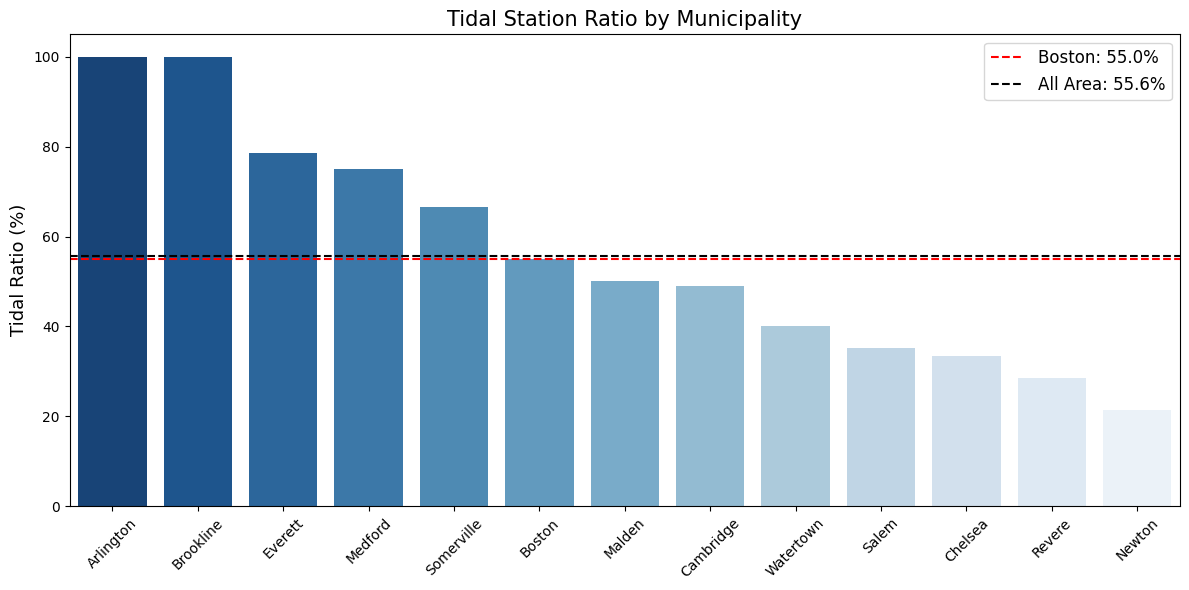

In [62]:
tidal_by_muni = []

for muni in df_net_flow['Municipality'].unique():
    muni_df = df_net_flow[df_net_flow['Municipality'] == muni]
    total = len(muni_df)
    tidal = len(muni_df[
        (muni_df['net_flow_morning'] < 0) & 
        (muni_df['net_flow_evening'] > 0)
    ])
    tidal_by_muni.append({
        'Municipality': muni,
        'Total Stations': total,
        'Tidal Stations': tidal,
        'Tidal Ratio': tidal / total * 100
    })

df_tidal_muni = pd.DataFrame(tidal_by_muni).sort_values('Tidal Ratio', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=df_tidal_muni, x='Municipality', y='Tidal Ratio',
            hue='Municipality', palette='Blues_r', legend=False, ax=ax)
ax.axhline(y=df_tidal_muni[df_tidal_muni['Municipality'] == 'Boston']['Tidal Ratio'].values[0],
           color='red', linestyle='--', label=f"Boston: {df_tidal_muni[df_tidal_muni['Municipality'] == 'Boston']['Tidal Ratio'].values[0]:.1f}%")
ax.axhline(y=total_tidal/total_stations*100,
           color='black', linestyle='--', label=f"All Area: {total_tidal/total_stations*100:.1f}%")
ax.set_title('Tidal Station Ratio by Municipality', fontsize=15)
ax.set_xlabel('')
ax.set_ylabel('Tidal Ratio (%)', fontsize=13)
ax.legend(fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Answer to Q3

In [63]:
print('for all stations')
print()
print("Top 10 highest full risk stations during evening peak:\n")
print("\n")
print(full_risk[['NAME', 'Municipality', 'Total Docks', 'net_flow_evening', 'flow_ratio']].head(10).to_string(index=False))

for all stations

Top 10 highest full risk stations during evening peak:



                                              NAME Municipality  Total Docks  net_flow_evening  flow_ratio
                   Inman Square at Springfield St.    Cambridge           25               981   39.240000
                       Valenti Way at Haverhill St       Boston           24               822   34.250000
                                W Broadway at D St       Boston           23               779   33.869565
Cambridge Dept. of Public Works -147 Hampshire St.    Cambridge           19               627   33.000000
           Sennott Park Broadway at Norfolk Street    Cambridge           19               603   31.736842
     Nashua Street at Red Auerbach Way [Extension]       Boston           32              1013   31.656250
                 Nashua Street at Red Auerbach Way       Boston           37              1153   31.162162
                         Union Square - Somerville   Somerville     

For cities in all area, Compared with empty risk, the full risks are more scattered in different areas. There are most situated in the residential areas. Generally, the residential areas suffer from full risk the most
Full risk coverage situation is listed as below: cambridge has 3 stations; Boston 4 stations; Brookline 2 stations; Somerville one station. 
Two stations in cambridge are residential areas.  W Broadway at D St in Boston, Cambridge Dept. of Public Works and Sennott Park Broadway at Norfolk Street in cambridge area, are all both in the top ten of empty risk and full risk. That says these stations have strong tide effect with large outflow in morning and inflow in evening. These stations need relancing operations. Bikes need to be refilled before the morning peak and removed after the evening peak. or else, these stations may suffer from the both empty risk in the morning and full risk in the evening very much, directly impacting rider experience at these high-traffic locations.

In [64]:
print('for Boston stations only')
print()
print("Top 10 highest full risk stations during evening peak:\n")
print(full_risk[full_risk['Municipality'] == 'Boston'][
    ['NAME', 'Total Docks', 'net_flow_evening', 'flow_ratio']
].head(10).to_string(index=False))

for Boston stations only

Top 10 highest full risk stations during evening peak:

                                         NAME  Total Docks  net_flow_evening  flow_ratio
                  Valenti Way at Haverhill St           24               822   34.250000
                           W Broadway at D St           23               779   33.869565
Nashua Street at Red Auerbach Way [Extension]           32              1013   31.656250
            Nashua Street at Red Auerbach Way           37              1153   31.162162
                  W Broadway at Dorchester St           17               510   30.000000
                 Washington St at Peters Park           19               552   29.052632
                  Tremont St at E Berkeley St           19               532   28.000000
                   Harvard Ave at Brainerd Rd           15               405   27.000000
                  Washington St at Waltham St           15               395   26.333333
            Massachusetts Av

Similar to the all area situation, the top 10 stations that suffer from full risks are most in the residential area. Intertestingly there are 5 stations in Boston that appear in both top 10 in empty risk and full risk, making them the very representative of tidal stations. compared with the all stations which only has 3 stations both in top in of empty risk and full risk, the boston city has five stations. Besides, overally the percentage of these tidal stations in boston city is higher than all over others. These says that many people live in boston and also work in bosont. The boston has a closed loop communte system. This can be a very valuable information for regulating blue bikes inside this boston commute system

## 4. Spatial Clustering
  - Do these phenomena show spatial clustering?
  - For example, do patterns differ between downtown/commercial areas and residential areas?

### rough overview 

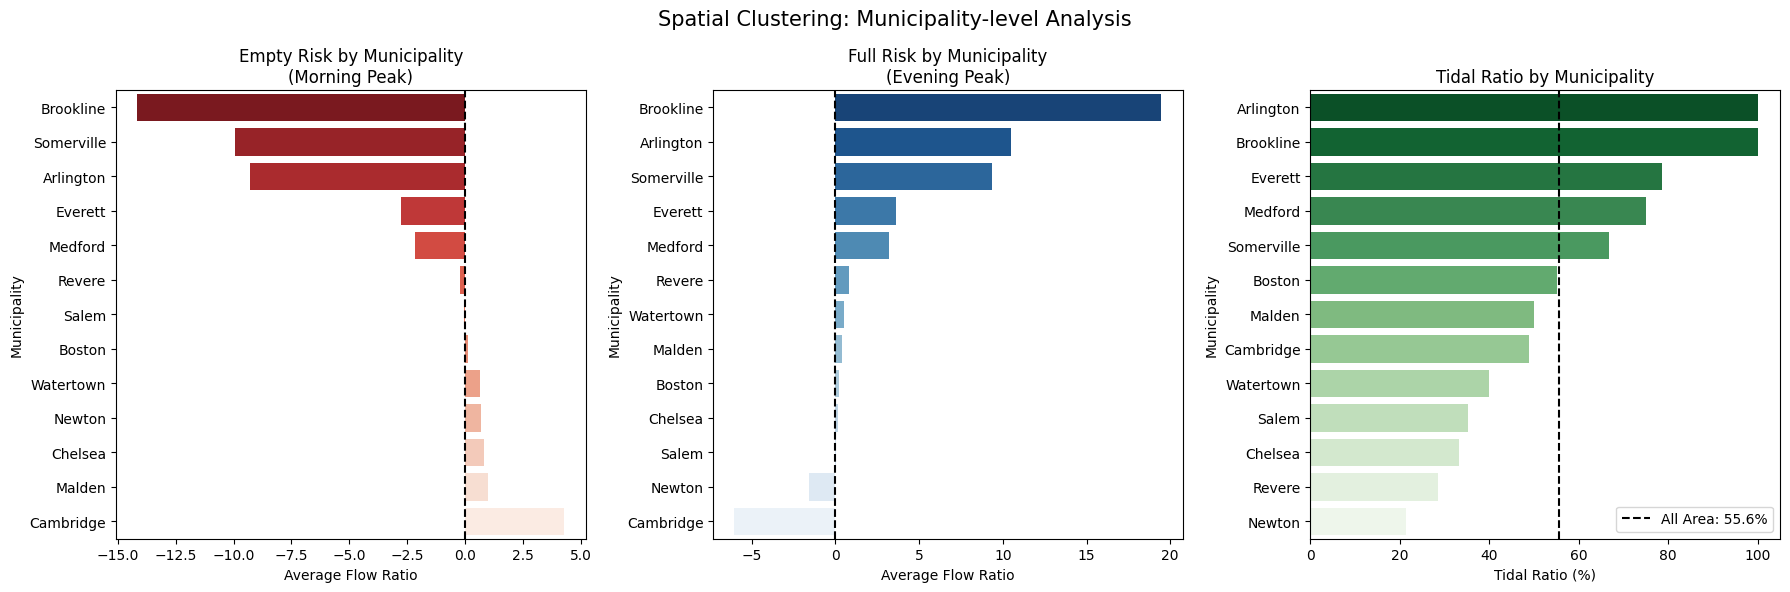

In [65]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Empty Risk by Municipality
empty_by_muni = empty_risk.groupby('Municipality')['flow_ratio'].mean().sort_values()
sns.barplot(data=empty_by_muni.reset_index(), 
            x='flow_ratio', y='Municipality',
            hue='Municipality', palette='Reds_r', 
            legend=False, ax=axes[0])
axes[0].axvline(x=0, color='black', linestyle='--')
axes[0].set_title('Empty Risk by Municipality\n(Morning Peak)')
axes[0].set_xlabel('Average Flow Ratio')

# Full Risk by Municipality
full_by_muni = full_risk.groupby('Municipality')['flow_ratio'].mean().sort_values(ascending=False)
sns.barplot(data=full_by_muni.reset_index(),
            x='flow_ratio', y='Municipality',
            hue='Municipality', palette='Blues_r',
            legend=False, ax=axes[1])
axes[1].axvline(x=0, color='black', linestyle='--')
axes[1].set_title('Full Risk by Municipality\n(Evening Peak)')
axes[1].set_xlabel('Average Flow Ratio')

# Tidal Ratio by Municipality
sns.barplot(data=df_tidal_muni,
            x='Tidal Ratio', y='Municipality',
            hue='Municipality', palette='Greens_r',
            legend=False, ax=axes[2])
axes[2].axvline(x=total_tidal/total_stations*100, 
                color='black', linestyle='--',
                label=f'All Area: {total_tidal/total_stations*100:.1f}%')
axes[2].set_title('Tidal Ratio by Municipality')
axes[2].set_xlabel('Tidal Ratio (%)')
axes[2].legend()

plt.suptitle('Spatial Clustering: Municipality-level Analysis', fontsize=15)
plt.tight_layout()
plt.show()

### spatial division in  Residential / Commercial / University / Mixed with Boston neighborhood boundaries

In [66]:
# Step 1: define function
def classify_area_all(row):
    muni = row['Municipality']
    residential_muni = ['Brookline', 'Arlington', 'Somerville', 
                        'Everett', 'Medford', 'Revere', 'Malden',
                        'Chelsea', 'Watertown']
    if muni in residential_muni:
        return 'Residential'
    elif muni in ['Newton', 'Salem']:
        return 'Commercial'
    elif muni == 'Cambridge':
        return 'University/Tech'  # no subdivision, treat as whole
    elif muni == 'Boston':
        downtown = ['Downtown', 'Back Bay', 'South Boston Waterfront', 
                    'Leather District', 'Chinatown', 
                    'North End', 'Beacon Hill']
        residential = ['Dorchester', 'Roxbury', 'Jamaica Plain', 
                       'Roslindale', 'Mattapan', 'Hyde Park', 
                       'West Roxbury', 'Brighton', 'Allston', 
                       'East Boston', 'South Boston', 'West End', 'Charlestown']
        neigh = row.get('neighborhood', '')
        if neigh in downtown:
            return 'Commercial'
        elif neigh in residential:
            return 'Residential'
        else:
            return 'Mixed/Medical'
    else:
        return 'Other'



# Step 2: load Boston neighborhood boundaries
import requests, geopandas as gpd
url = "https://data.boston.gov/dataset/bf1a7b50-4c72-4637-b0fa-11d632e3aff1/resource/e5849875-a6f6-4c9c-9d8a-5048b0fbd03e/download/boston_neighborhood_boundaries.geojson"
response = requests.get(url)
boston_boundary = gpd.GeoDataFrame.from_features(
    response.json()["features"], crs="EPSG:4326"
)

# Step 3: get Boston stations with coordinates
boston_only = df_net_flow[df_net_flow['Municipality'] == 'Boston'].copy()
boston_only = boston_only.reset_index().merge(
    stations[['Number', 'Lat', 'Long']], on='Number', how='left'
)

# Step 4: spatial join
boston_gdf = gpd.GeoDataFrame(
    boston_only,
    geometry=gpd.points_from_xy(boston_only['Long'], boston_only['Lat']),
    crs='EPSG:4326'
)
boston_with_neigh = gpd.sjoin(
    boston_gdf,
    boston_boundary[['geometry', 'name']],
    how='left', predicate='within'
).rename(columns={'name': 'neighborhood'})
print(f"Total Boston stations: {len(boston_with_neigh)}")
print(f"Stations matched to neighborhood: {boston_with_neigh['neighborhood'].notna().sum()}")

# Step 5: create df_net_flow_area
df_net_flow_area = df_net_flow.copy().reset_index()
neigh_map = boston_with_neigh.set_index('Number')['neighborhood'].to_dict()
df_net_flow_area['neighborhood'] = df_net_flow_area['Number'].map(neigh_map)

# Step 6: apply simple classification
df_net_flow_area['area_type'] = df_net_flow_area.apply(classify_area_all, axis=1)
print("Simple classification:")
print(df_net_flow_area['area_type'].value_counts())


Total Boston stations: 338
Stations matched to neighborhood: 338
Simple classification:
area_type
Residential        336
Commercial         103
University/Tech     92
Mixed/Medical       52
Name: count, dtype: int64


Global View Summary:
                 station_count  avg_morning_flow  avg_evening_flow  \
area_type                                                            
Commercial                 103            167.19           -155.93   
Mixed/Medical               52             57.73            -12.42   
Residential                336            -84.91             84.99   
University/Tech             92             90.28           -128.80   

                 avg_reversal  
area_type                      
Commercial            -323.13  
Mixed/Medical          -70.15  
Residential            169.90  
University/Tech       -219.09  


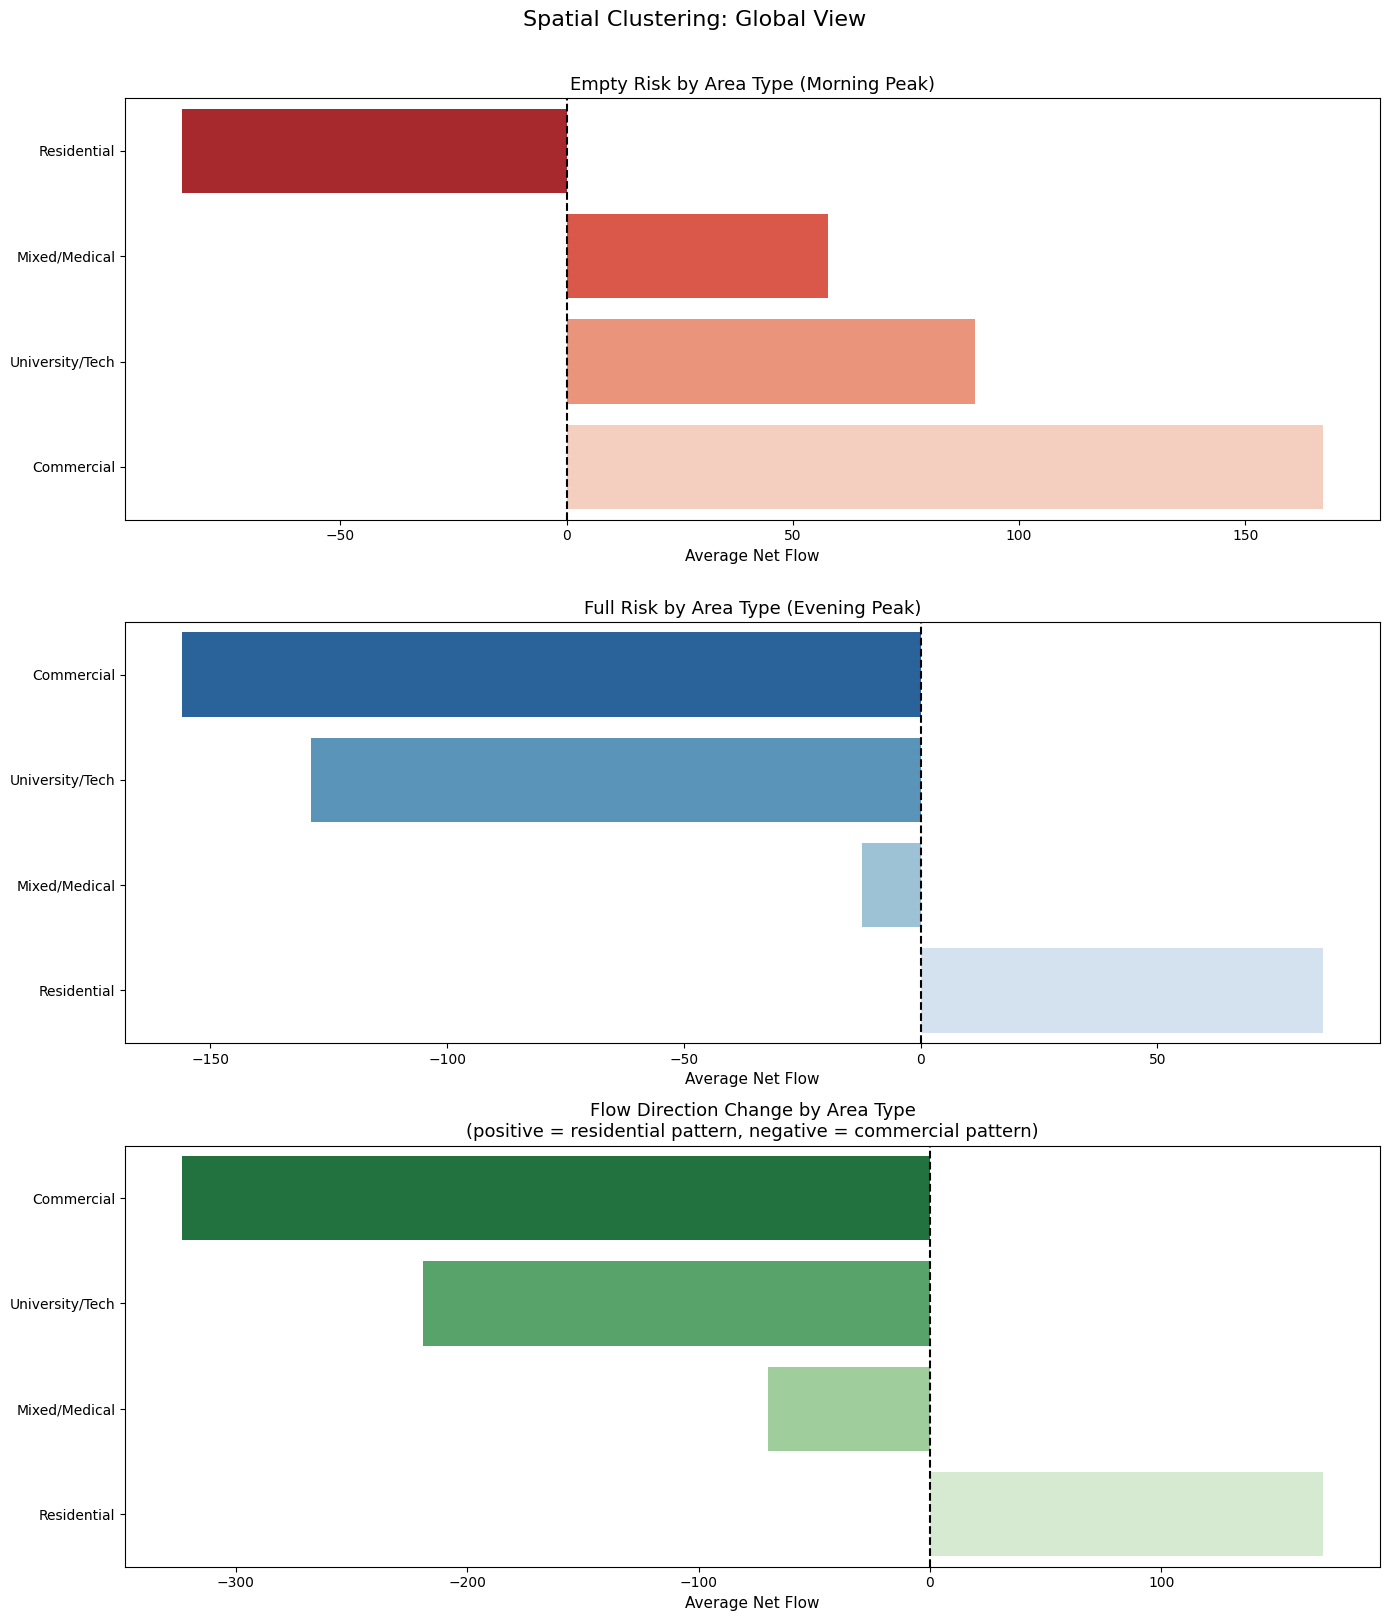

In [67]:
def plot_spatial_clustering(summary_df, group_col, title):
    """Plot spatial clustering analysis for a given grouping column"""
    
    # reshape to long format
    summary_long = summary_df[
        ['avg_morning_flow', 'avg_evening_flow', 'avg_reversal']
    ].reset_index().melt(
        id_vars=group_col,
        value_vars=['avg_morning_flow', 'avg_evening_flow', 'avg_reversal'],
        var_name='Metric',
        value_name='Value'
    )
    summary_long['Metric'] = summary_long['Metric'].map({
        'avg_morning_flow': 'Morning Net Flow\n(Empty Risk)',
        'avg_evening_flow': 'Evening Net Flow\n(Full Risk)',
        'avg_reversal': 'Flow Direction Change\n(Evening - Morning)'
    })
    metrics = [
        ('Morning Net Flow\n(Empty Risk)', 'Reds_r', 
         'Empty Risk by Area Type (Morning Peak)'),
        ('Evening Net Flow\n(Full Risk)', 'Blues_r', 
         'Full Risk by Area Type (Evening Peak)'),
        ('Flow Direction Change\n(Evening - Morning)', 'Greens_r', 
         'Flow Direction Change by Area Type\n(positive = residential pattern, negative = commercial pattern)')
    ]
    fig, axes = plt.subplots(3, 1, figsize=(14, 16))
    for i, (metric, palette, subtitle) in enumerate(metrics):
        data = summary_long[
            summary_long['Metric'] == metric
        ].sort_values('Value')
        sns.barplot(data=data, x='Value', y=group_col,
                    hue=group_col, palette=palette,
                    legend=False, ax=axes[i])
        axes[i].axvline(x=0, color='black', linestyle='--')
        axes[i].set_title(subtitle, fontsize=13)
        axes[i].set_xlabel('Average Net Flow', fontsize=11)
        axes[i].set_ylabel('')
    plt.suptitle(title, fontsize=16, y=1.01)
    plt.tight_layout()
    plt.show()

summary_simple = df_net_flow_area.groupby('area_type').agg(
    station_count=('Number', 'count'),
    avg_morning_flow=('net_flow_morning', 'mean'),
    avg_evening_flow=('net_flow_evening', 'mean'),
    avg_reversal=('reversal', 'mean')
).round(2)
print("Global View Summary:")
print(summary_simple)
plot_spatial_clustering(summary_simple, 'area_type', 
                        'Spatial Clustering: Global View')

### for only boston area 

boston_area_type
Residential            220
Downtown/Commercial     72
Mixed/Medical           46
Name: count, dtype: int64
                     station_count  avg_morning_flow  avg_evening_flow  \
boston_area_type                                                         
Downtown/Commercial             72            237.01           -218.67   
Mixed/Medical                   46             79.26             -9.70   
Residential                    220            -80.59             69.87   

                     avg_reversal  
boston_area_type                   
Downtown/Commercial       -455.68  
Mixed/Medical              -88.96  
Residential                150.45  


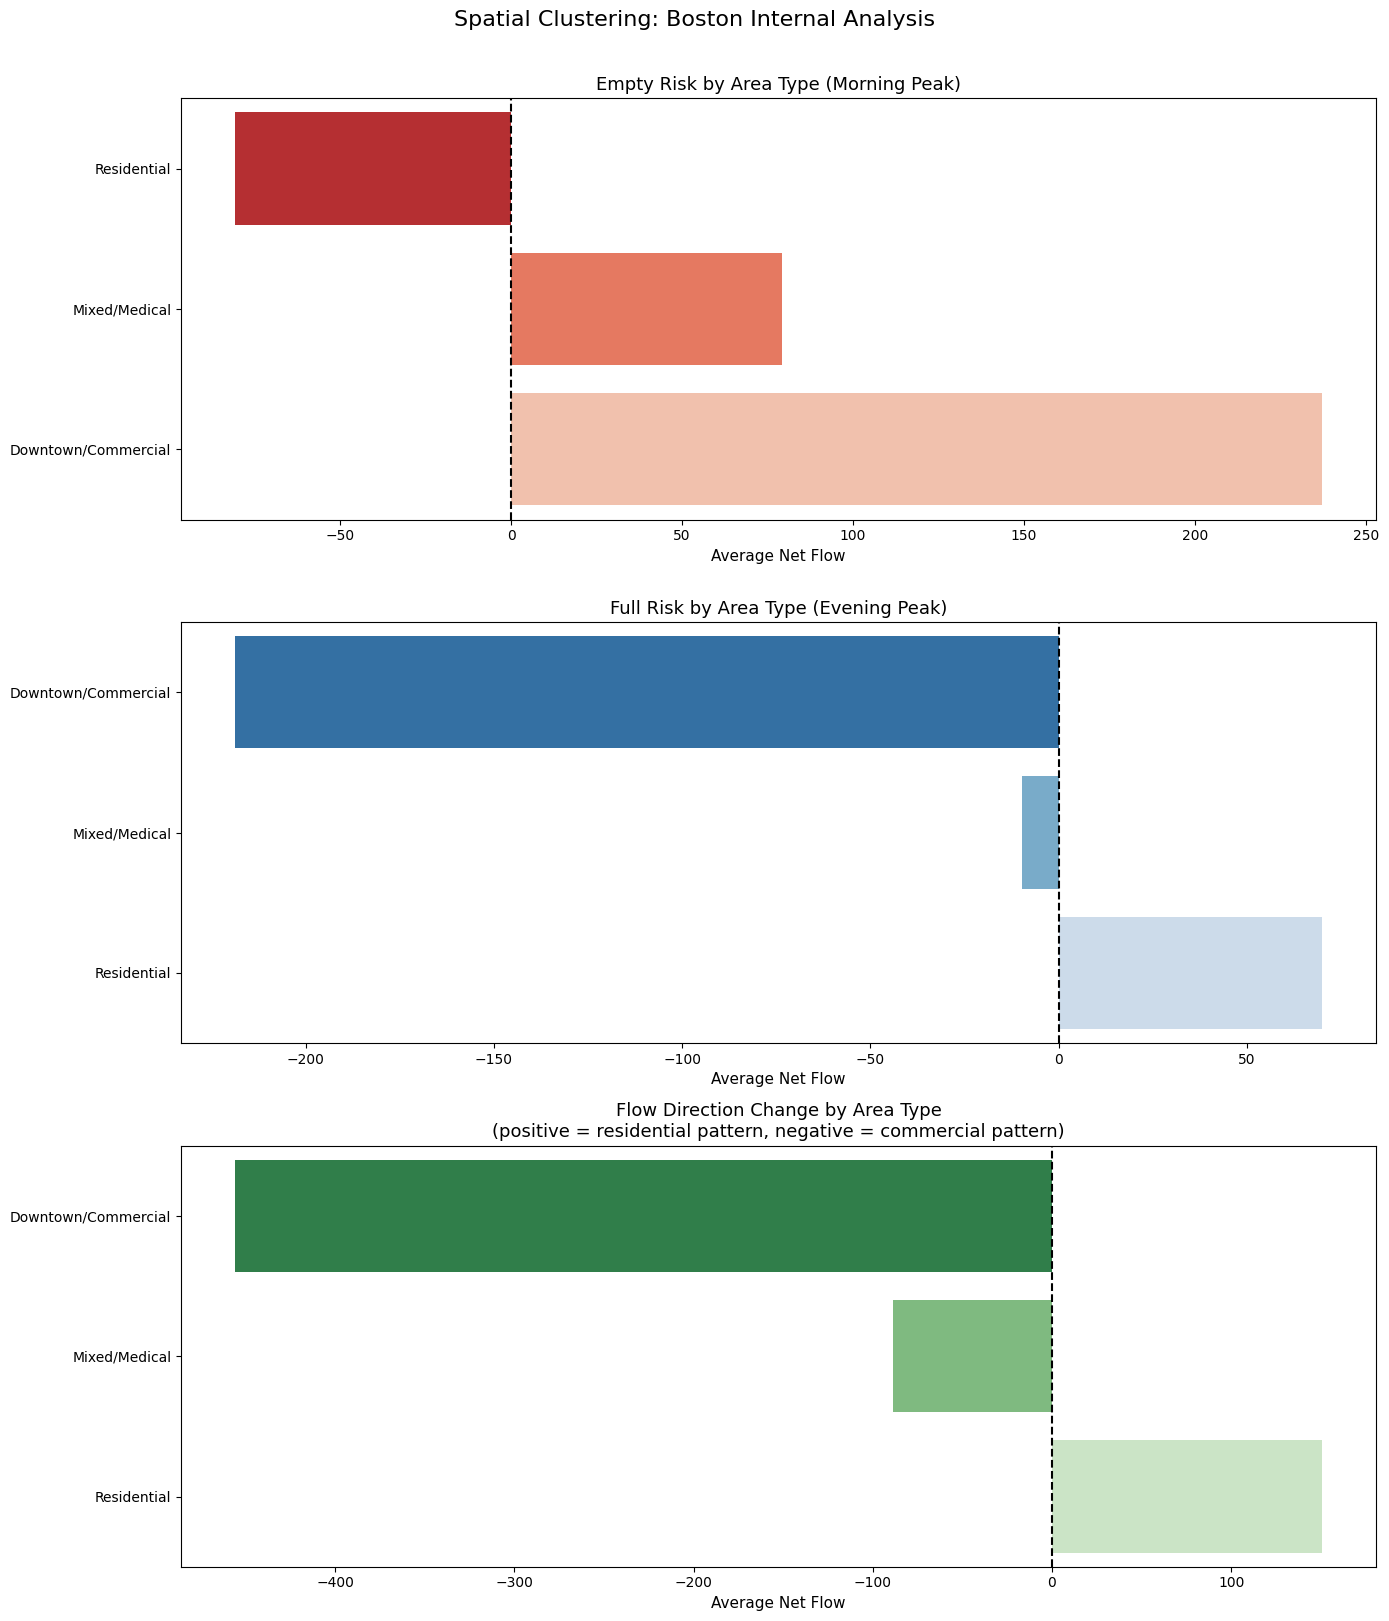

In [68]:
def classify_only_boston(row):
    downtown = ['Downtown', 'Back Bay', 'South Boston Waterfront', 
                'Leather District', 'Chinatown', 
                'North End', 'Beacon Hill']
    residential = ['Dorchester', 'Roxbury', 'Jamaica Plain', 
                   'Roslindale', 'Mattapan', 'Hyde Park', 
                   'West Roxbury', 'Brighton', 'Allston', 
                   'East Boston', 'South Boston', 'Charlestown',
                   'Mission Hill',  
                   'West End']     
    mixed = ['Longwood', 'Fenway', 'South End']  
    
    neigh = row.get('neighborhood', '')
    if neigh in downtown:
        return 'Downtown/Commercial'
    elif neigh in residential:
        return 'Residential'
    elif neigh in mixed:
        return 'Mixed/Medical'
    else:
        return 'Mixed/Medical'  # default

# get only boston stations
boston_area_only = df_net_flow_area[df_net_flow_area['Municipality'] == 'Boston'].copy()
boston_area_only['boston_area_type'] = boston_area_only.apply(classify_only_boston, axis=1)
print(boston_area_only['boston_area_type'].value_counts())

# summary and plot
summary_boston = boston_area_only.groupby('boston_area_type').agg(
    station_count=('Number', 'count'),
    avg_morning_flow=('net_flow_morning', 'mean'),
    avg_evening_flow=('net_flow_evening', 'mean'),
    avg_reversal=('reversal', 'mean')
).round(2)
print(summary_boston)

plot_spatial_clustering(summary_boston, 'boston_area_type',
                        'Spatial Clustering: Boston Internal Analysis')

In [69]:
# Boston internal - neighborhood level analysis
# get only boston stations
boston_area_only = df_net_flow_area[df_net_flow_area['Municipality'] == 'Boston'].copy()
boston_area_only['boston_area_type'] = boston_area_only.apply(classify_only_boston, axis=1)
print(boston_area_only['boston_area_type'].value_counts())

boston_neigh_summary = boston_area_only.groupby('neighborhood').agg(
    station_count=('Number', 'count'),
    avg_morning_flow=('net_flow_morning', 'mean'),
    avg_evening_flow=('net_flow_evening', 'mean'),
    avg_reversal=('reversal', 'mean')
).round(2).dropna()

print(f"Total neighborhoods: {len(boston_neigh_summary)}")
print(boston_neigh_summary.sort_values('avg_morning_flow'))

boston_area_type
Residential            220
Downtown/Commercial     72
Mixed/Medical           46
Name: count, dtype: int64
Total neighborhoods: 24
                         station_count  avg_morning_flow  avg_evening_flow  \
neighborhood                                                                 
West End                             7           -417.86            503.71   
North End                            4           -359.00            354.25   
South Boston                        12           -254.42            308.92   
South End                           18           -154.44            195.72   
Allston                             26           -117.15            120.77   
Mission Hill                         6           -107.33            -33.33   
Brighton                            20            -94.05             63.50   
Roxbury                             25            -84.44             37.20   
Jamaica Plain                       16            -79.56             83.

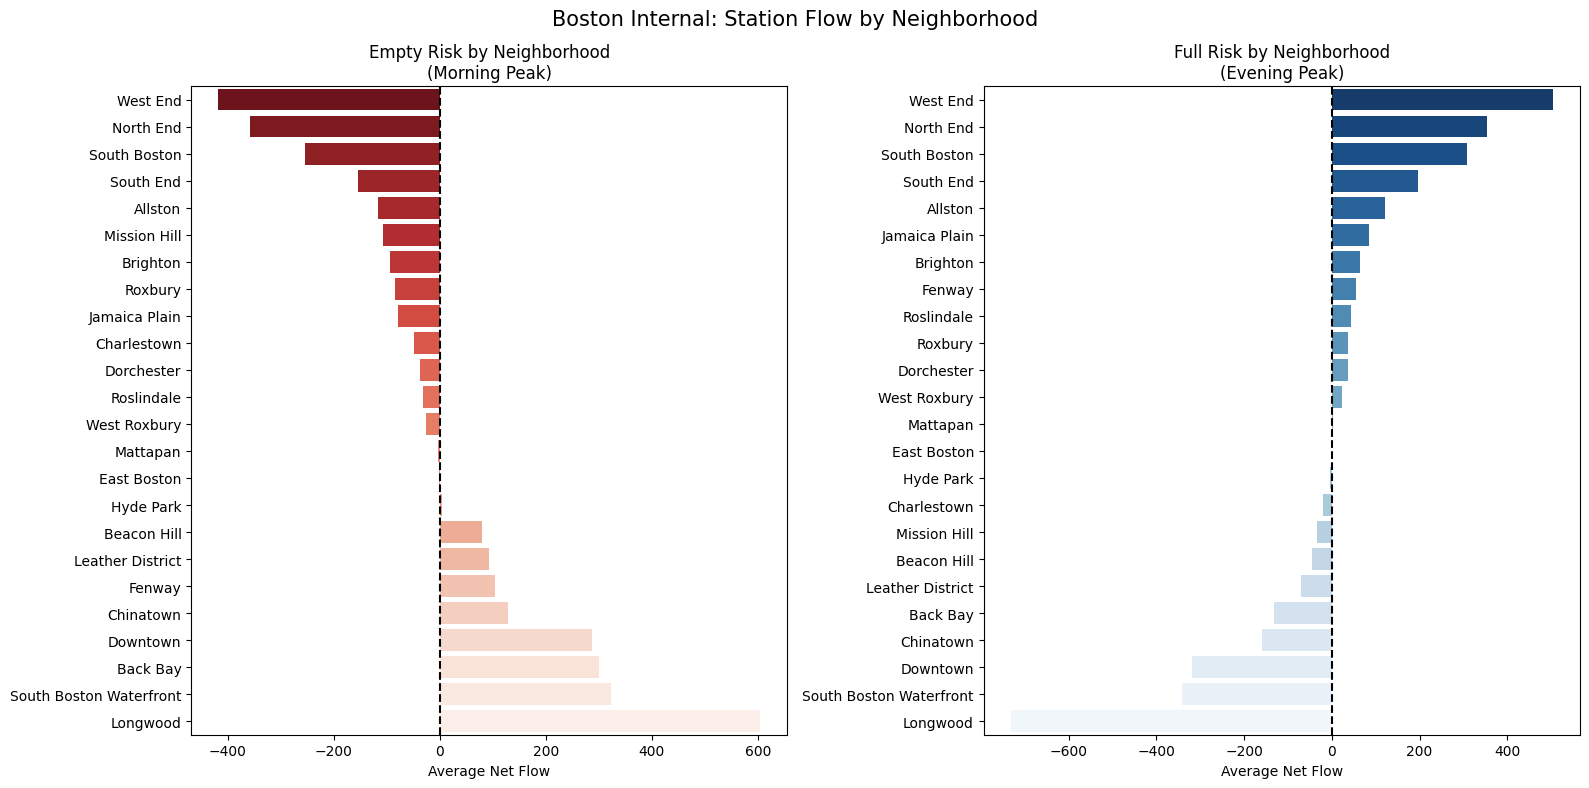

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Empty Risk by Neighborhood
empty_by_neigh = boston_neigh_summary['avg_morning_flow'].sort_values().reset_index()
empty_by_neigh.columns = ['neighborhood', 'avg_morning_flow']
sns.barplot(data=empty_by_neigh, x='avg_morning_flow', y='neighborhood',
            hue='neighborhood', palette='Reds_r', legend=False, ax=axes[0])
axes[0].axvline(x=0, color='black', linestyle='--')
axes[0].set_title('Empty Risk by Neighborhood\n(Morning Peak)')
axes[0].set_xlabel('Average Net Flow')
axes[0].set_ylabel('')

# Full Risk by Neighborhood
full_by_neigh = boston_neigh_summary['avg_evening_flow'].sort_values(ascending=False).reset_index()
full_by_neigh.columns = ['neighborhood', 'avg_evening_flow']
sns.barplot(data=full_by_neigh, x='avg_evening_flow', y='neighborhood',
            hue='neighborhood', palette='Blues_r', legend=False, ax=axes[1])
axes[1].axvline(x=0, color='black', linestyle='--')
axes[1].set_title('Full Risk by Neighborhood\n(Evening Peak)')
axes[1].set_xlabel('Average Net Flow')
axes[1].set_ylabel('')

plt.suptitle('Boston Internal: Station Flow by Neighborhood', fontsize=15)
plt.tight_layout()
plt.show()

### Answer to Q4

yes these phenomena shows the spatial clustering.
from the graph we can see there is a clear tendency that in residential area, pepeole depart from the statations by bike in the morning peak and returns back to the station in the evening. The residential area is a representative tidal station. While for commerical area, it can be said as a tidal station in reverse way with more arriving in morning and departing in the evening. Besides, we can see the direction change degree is very big in commerical area, It is understanding since it is a transforportion hub with many arriving and departing.

At the municipality level, residential cities such as Brookline, Arlington and Somerville demonstrates the highest empty risk in am and full risk in pm, while Cambridge as a University/Tech hub shows net inflow in the morning. Although MIT and Harvard campus stations individually experience high empty risk  as students frequently ride bikes across large campuses where parking is very difficult, the strong inflow of tech employeess flow into areas like Kendall Square offsets the outflow like from students riding out, resulting in a moderate positive net flow for Cambridge generally, making cambridge empty risk manageable and full risk low in the evening.

because boston has many areas, it has to be divided into more detailed parts. Boston using official neighborhood boundaries, the same pattern holds internally. Downtown/Commercial areas show the strongest flow direction change in absolute terms, confirming Boston Downtown as the most active commuting hub in the system. Residential neighborhoods such as Allston show the classic tidal pattern, while Mixed/Medical areas fall in between, reflecting their mixed land use character.

A notable exception is the Longwood Medical Area, which shows the largest net inflow in the morning and largest net outflow in the evening among all Boston neighborhoods even exceeding Downtown. This reflects the unique nature of the medical district, where thousands of healthcare workers commute daily to major hospitals including Brigham and Women's, Boston Children's, and Beth Israel Deaconess. Longwood operates essentially as a "medical campus destination", similar to how Cambridge functions as a university and tech destination.
Spatial clustering is confirmed at two levels:

Cross-municipality: Residential cities vs Commercial/University municipalities show perfectly opposite patterns
Within Boston: Downtown/Commercial vs Residential neighborhoods show the same opposing pattern, with Longwood/Medical standing out as a distinct third cluster with many hospitals there

This confirms that land use type is the primary driver of spatial clustering. commuting behavior driven by where people study live and work determines the direction and timing of bike flow across the entire Bluebikes system. 

These peaks happen during cetain time span and is obvious in weekdays. stations with big full risk and empty risk are worth the more manual bike regulating effors to improve the user experience.
These findings have direct operational implications: rebalancing strategies should be tailored to area type, with bikes moved from residential to commercial areas in the morning and returned in the evening.

## 5. Visualization
  - Use standard visualization methods to communicate your results clearly.

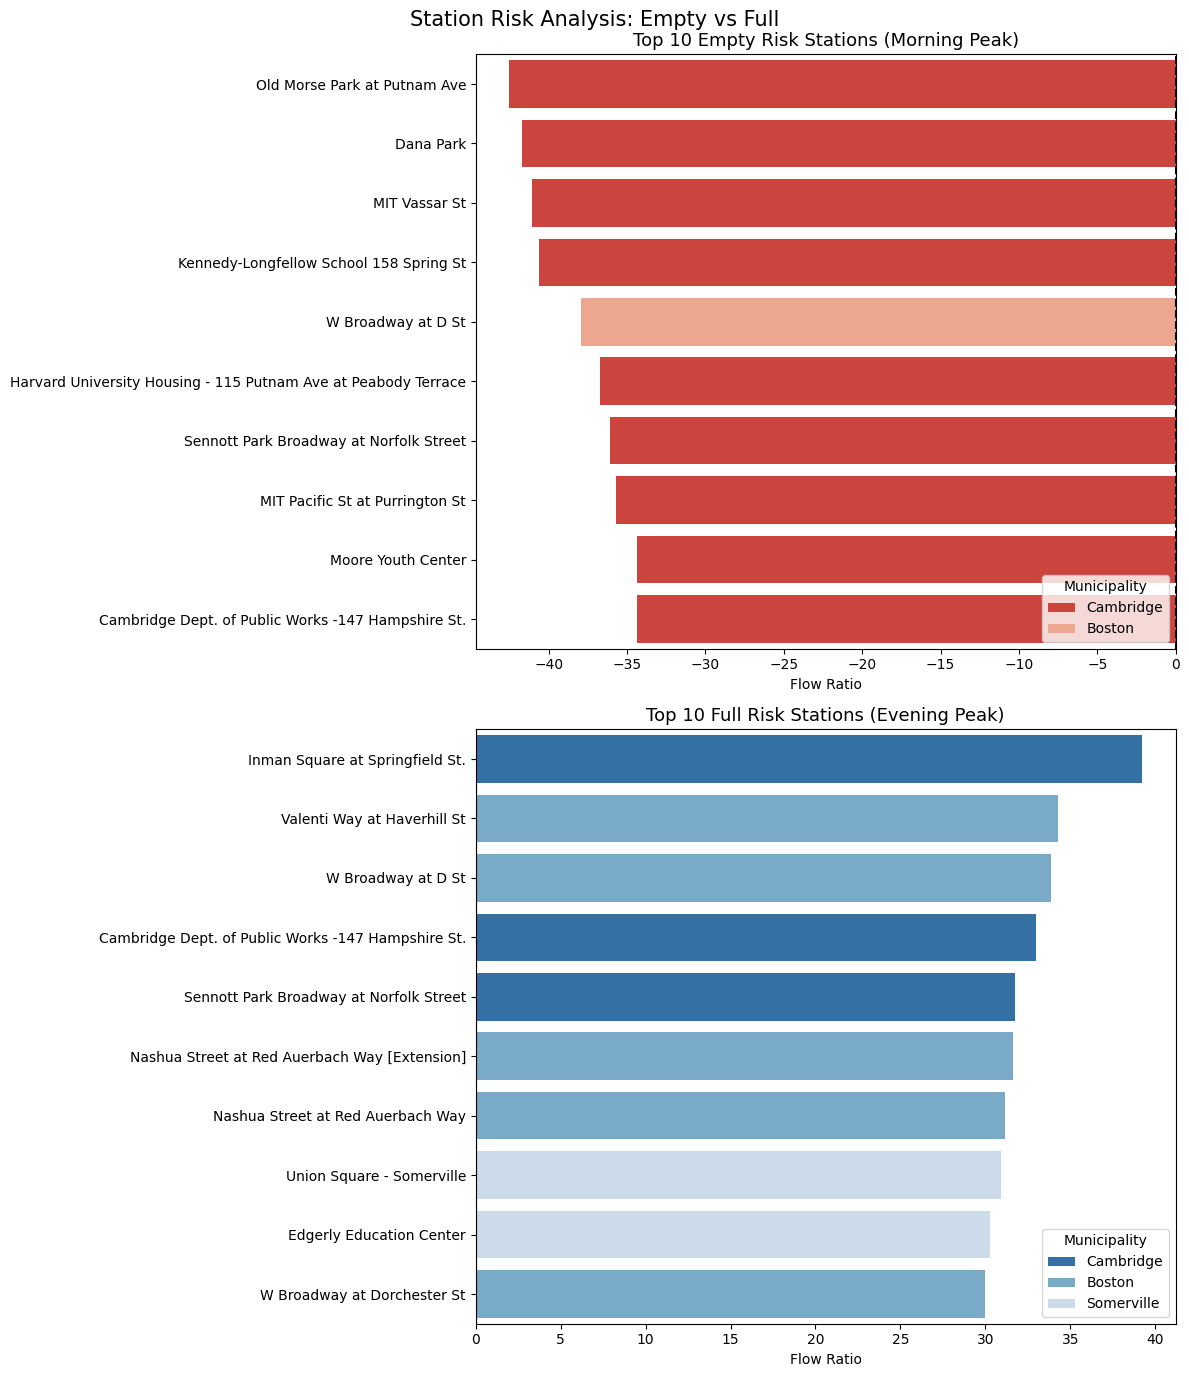

In [71]:
fig, axes = plt.subplots(2, 1, figsize=(12, 14))

#top ten empty station in the morning
sns.barplot(data=empty_risk.head(10), x='flow_ratio', y='NAME',
            hue='Municipality', palette='Reds_r', ax=axes[0])
axes[0].axvline(x=0, color='black', linestyle='--')
axes[0].set_title('Top 10 Empty Risk Stations (Morning Peak)', fontsize=13)
axes[0].set_xlabel('Flow Ratio')
axes[0].set_ylabel('')
axes[0].legend(title='Municipality', loc='lower right')

# top ten full station in the evening
sns.barplot(data=full_risk.head(10), x='flow_ratio', y='NAME',
            hue='Municipality', palette='Blues_r', ax=axes[1])
axes[1].axvline(x=0, color='black', linestyle='--')
axes[1].set_title('Top 10 Full Risk Stations (Evening Peak)', fontsize=13)
axes[1].set_xlabel('Flow Ratio')
axes[1].set_ylabel('')
axes[1].legend(title='Municipality', loc='lower right')

plt.suptitle('Station Risk Analysis: Empty vs Full', fontsize=15)
plt.tight_layout()
plt.show()

In [72]:
import subprocess
import sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'plotly'])


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: /Users/linlinfan/DAMG6105 _python_for_Data/Project/.venv/bin/python3 -m pip install --upgrade pip


0

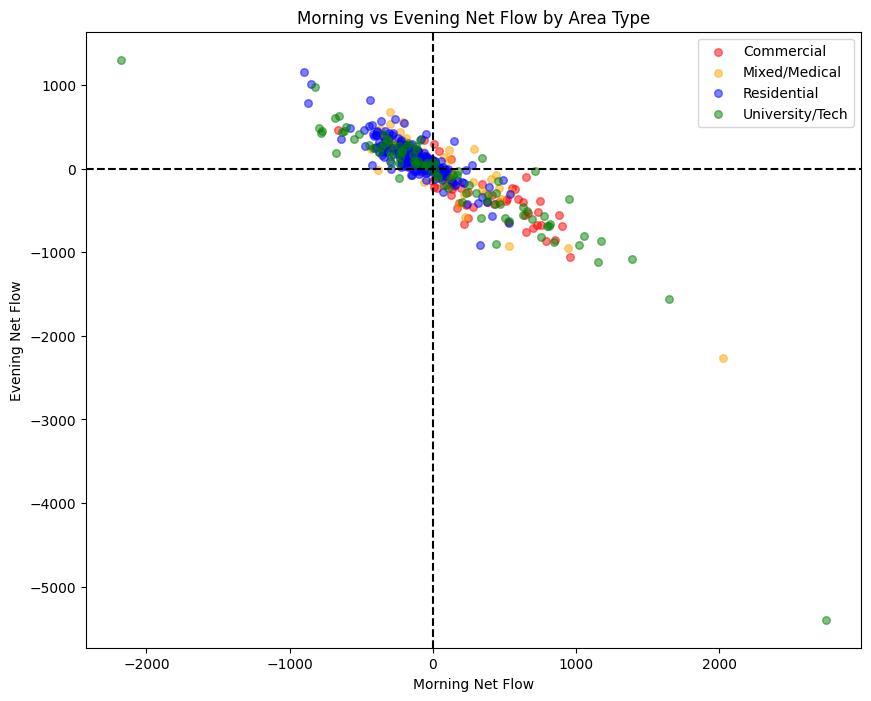

In [73]:
fig, ax = plt.subplots(figsize=(10, 8))
colors = {'Residential': 'blue', 'Commercial': 'red',
          'University/Tech': 'green', 'Mixed/Medical': 'orange'}
for area, group in df_net_flow_area.groupby('area_type'):
    ax.scatter(group['net_flow_morning'], group['net_flow_evening'],
               c=colors.get(area, 'grey'), label=area, alpha=0.5, s=30)
ax.axhline(y=0, color='black', linestyle='--')
ax.axvline(x=0, color='black', linestyle='--')
ax.set_xlabel('Morning Net Flow')
ax.set_ylabel('Evening Net Flow')
ax.set_title('Morning vs Evening Net Flow by Area Type')
ax.legend()

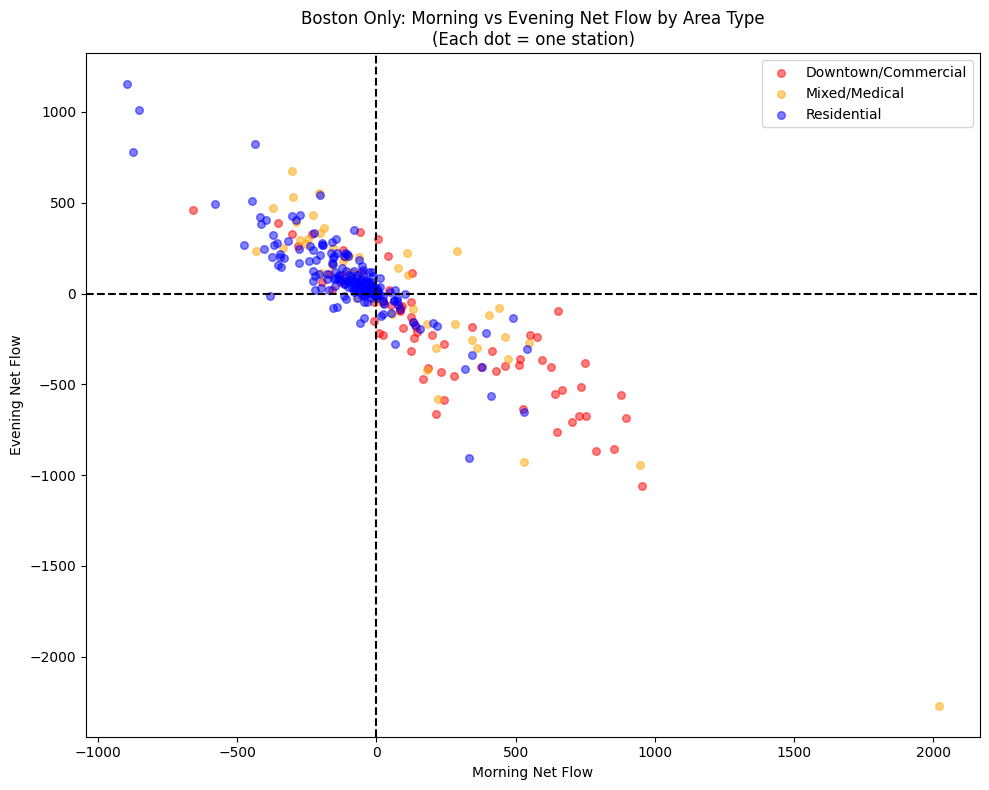

In [74]:
fig, ax = plt.subplots(figsize=(10, 8))

colors_boston = {
    'Downtown/Commercial': 'red',
    'Residential': 'blue',
    'Mixed/Medical': 'orange'
}

for area, group in boston_area_only.groupby('boston_area_type'):
    ax.scatter(group['net_flow_morning'], group['net_flow_evening'],
               c=colors_boston.get(area, 'grey'), label=area, alpha=0.5, s=30)

ax.axhline(y=0, color='black', linestyle='--')
ax.axvline(x=0, color='black', linestyle='--')
ax.set_xlabel('Morning Net Flow')
ax.set_ylabel('Evening Net Flow')
ax.set_title('Boston Only: Morning vs Evening Net Flow by Area Type\n(Each dot = one station)')
ax.legend()
plt.tight_layout()
plt.show()

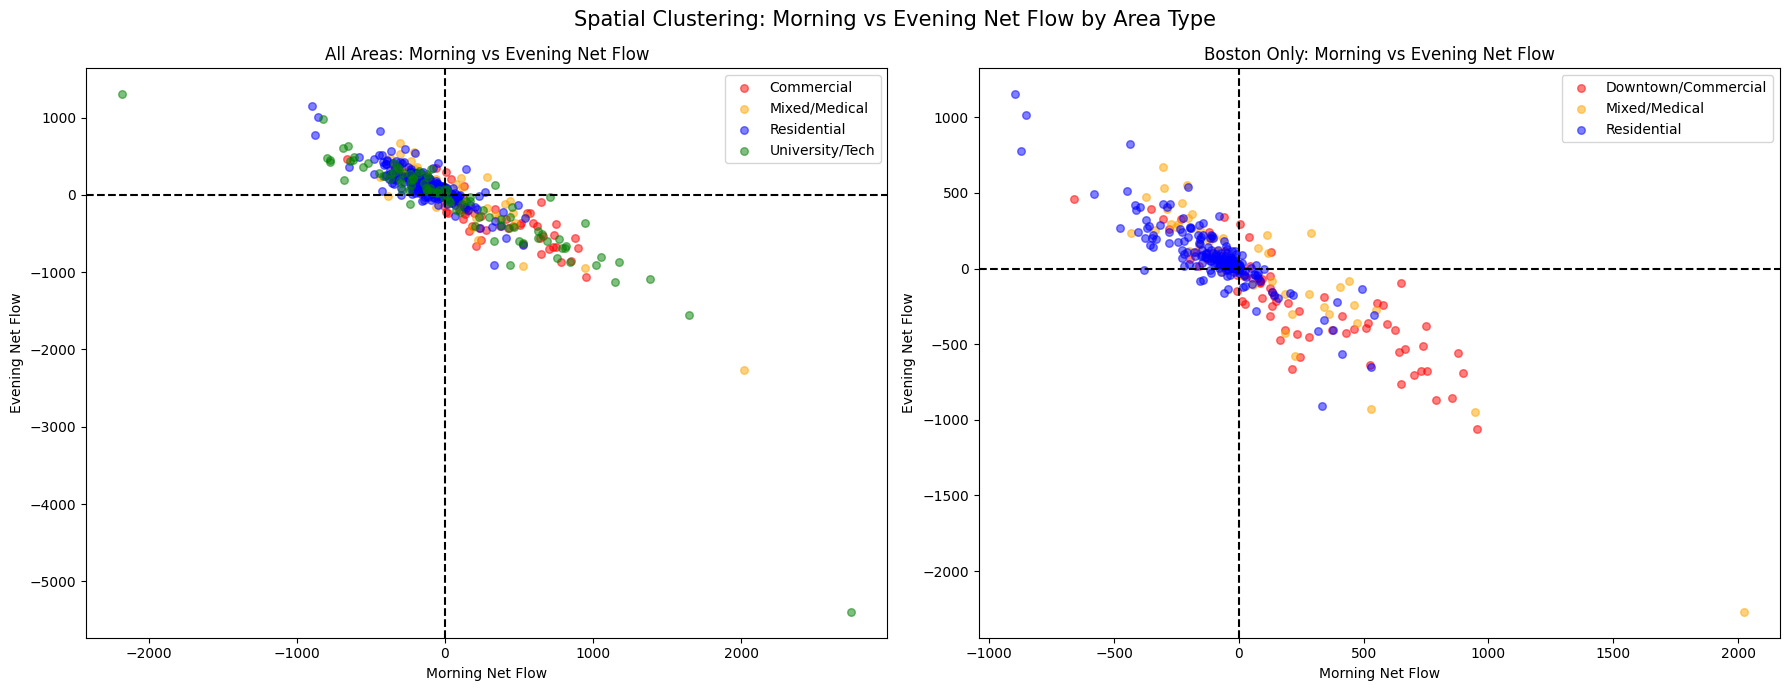

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

colors = {
    'Residential': 'blue',
    'Commercial': 'red',
    'University/Tech': 'green',
    'Mixed/Medical': 'orange',
    'Other': 'grey'
}

# All Areas On the left
for area, group in df_net_flow_area.groupby('area_type'):
    axes[0].scatter(group['net_flow_morning'], group['net_flow_evening'],
                    c=colors.get(area, 'grey'), label=area, alpha=0.5, s=30)
axes[0].axhline(y=0, color='black', linestyle='--')
axes[0].axvline(x=0, color='black', linestyle='--')
axes[0].set_xlabel('Morning Net Flow')
axes[0].set_ylabel('Evening Net Flow')
axes[0].set_title('All Areas: Morning vs Evening Net Flow')
axes[0].legend()

# Boston Only on the right
colors_boston = {
    'Downtown/Commercial': 'red',
    'Residential': 'blue',
    'Mixed/Medical': 'orange'
}
for area, group in boston_area_only.groupby('boston_area_type'):
    axes[1].scatter(group['net_flow_morning'], group['net_flow_evening'],
                    c=colors_boston.get(area, 'grey'), label=area, alpha=0.5, s=30)
axes[1].axhline(y=0, color='black', linestyle='--')
axes[1].axvline(x=0, color='black', linestyle='--')
axes[1].set_xlabel('Morning Net Flow')
axes[1].set_ylabel('Evening Net Flow')
axes[1].set_title('Boston Only: Morning vs Evening Net Flow')
axes[1].legend()

plt.suptitle('Spatial Clustering: Morning vs Evening Net Flow by Area Type', fontsize=15)
plt.tight_layout()
plt.show()

### Bonus Question

Map-based visualization:
- Display your findings on a map, highlighting in particular the risk of empty stations in the morning, full stations in the evening, or supply-demand imbalances during peak hours at the station level.

In [76]:
empty_risk_map = empty_risk.merge(
    stations[['Number', 'Lat', 'Long']],
    on='Number',
    how='left'
).dropna(subset=['Lat', 'Long'])

full_risk_map = full_risk.merge(
    stations[['Number', 'Lat', 'Long']],
    on='Number',
    how='left'
).dropna(subset=['Lat', 'Long'])

reversal_map = df_net_flow.merge(
    stations[['Number', 'Lat', 'Long']],
    left_index=True,
    right_on='Number',
    how='left'
).dropna(subset=['Lat', 'Long'])

print(f"empty_risk_map: {len(empty_risk_map)} stations")
print(f"full_risk_map: {len(full_risk_map)} stations")
print(f"reversal_map: {len(reversal_map)} stations")

empty_risk_map: 583 stations
full_risk_map: 583 stations
reversal_map: 583 stations


In [77]:
import folium
from folium import plugins

m = folium.Map(location=[42.36, -71.08], zoom_start=12)


empty_layer = folium.FeatureGroup(name='Empty Risk (Morning Peak)', show=True)
full_layer = folium.FeatureGroup(name='Full Risk (Evening Peak)', show=True)
imbalance_layer = folium.FeatureGroup(name='Supply-Demand Imbalance (Reversal)', show=False)

reversal_map = df_net_flow.merge(
    stations[['Number', 'Lat', 'Long']],
    left_index=True,
    right_on='Number',
    how='left'
).dropna(subset=['Lat', 'Long'])


empty_min = empty_risk_map['flow_ratio'].min()
reversal_max = reversal_map['reversal'].abs().max()

for _, row in empty_risk_map.iterrows():
    intensity = min(abs(row['flow_ratio'] / empty_min), 1.0)
    folium.CircleMarker(
        location=[row['Lat'], row['Long']],
        radius=3 + intensity * 10,
        color='red',
        fill=True,
        fill_color='red',
        fill_opacity=0.3 + intensity * 0.6,
        tooltip=f"⚠️ {row['NAME']}",
        popup=folium.Popup(
            f"<b>{row['NAME']}</b><br>"
            f"Municipality: {row['Municipality']}<br>"
            f"Empty Risk Ratio: {row['flow_ratio']:.1f}",
            max_width=200
        )
    ).add_to(empty_layer)

full_max = full_risk_map['flow_ratio'].max()
for _, row in full_risk_map.iterrows():
    intensity = min(abs(row['flow_ratio'] / full_max), 1.0)
    folium.CircleMarker(
        location=[row['Lat'], row['Long']],
        radius=3 + intensity * 10,
        color='blue',
        fill=True,
        fill_color='blue',
        fill_opacity=0.3 + intensity * 0.6,
        tooltip=f"🚲 {row['NAME']}",
        popup=folium.Popup(
            f"<b>{row['NAME']}</b><br>"
            f"Municipality: {row['Municipality']}<br>"
            f"Full Risk Ratio: {row['flow_ratio']:.1f}",
            max_width=200
        )
    ).add_to(full_layer)

for _, row in reversal_map.iterrows():
    intensity = min(abs(row['reversal']) / reversal_max, 1.0)
    color = 'green' if row['reversal'] > 0 else 'purple'
    folium.CircleMarker(
        location=[row['Lat'], row['Long']],
        radius=3 + intensity * 10,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.3 + intensity * 0.6,
        tooltip=f"{'🏠 Residential' if row['reversal'] > 0 else '🏢 Commercial'}: {row['NAME']}",
        popup=folium.Popup(
            f"<b>{row['NAME']}</b><br>"
            f"Municipality: {row['Municipality']}<br>"
            f"Reversal: {row['reversal']:.0f}<br>"
            f"Morning: {row['net_flow_morning']:.0f}<br>"
            f"Evening: {row['net_flow_evening']:.0f}",
            max_width=200
        )
    ).add_to(imbalance_layer)

imbalance_layer.add_to(m)
empty_layer.add_to(m)
full_layer.add_to(m)


folium.LayerControl().add_to(m)

legend_html = '''
<div style="position: fixed; bottom: 50px; left: 50px; 
     background-color: white; padding: 10px; border-radius: 5px;
     border: 2px solid grey; font-size: 14px; z-index: 1000;">
    <b>Station Risk Legend</b><br>
    <span style="color:red;">●</span> Empty Risk (Morning Peak)<br>
    <span style="color:blue;">●</span> Full Risk (Evening Peak)<br>
    <span style="color:green;">●</span> Imbalance: Residential (Tidal)<br>
    <span style="color:purple;">●</span> Imbalance: Commercial (Reverse)<br>
    <i>Circle size & opacity = risk intensity</i><br>
    <i>Use layer control (top right) to toggle layers</i>
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))
print(f"empty_risk_map: {len(empty_risk_map)} stations")
print(f"full_risk_map: {len(full_risk_map)} stations")

m.save('bluebikes_risk_map.html')
m

empty_risk_map: 583 stations
full_risk_map: 583 stations


In [78]:
# Boston Internal Map
m_boston = folium.Map(location=[42.33, -71.08], zoom_start=13)

# only get stations in Boston 
boston_empty = empty_risk_map[empty_risk_map['Municipality'] == 'Boston']
boston_full = full_risk_map[full_risk_map['Municipality'] == 'Boston']
boston_reversal = reversal_map[reversal_map['Municipality'] == 'Boston']  

empty_layer_bos = folium.FeatureGroup(name='Empty Risk (Morning Peak)', show=True)
full_layer_bos = folium.FeatureGroup(name='Full Risk (Evening Peak)', show=True)
imbalance_layer_bos = folium.FeatureGroup(name='Supply-Demand Imbalance (Reversal)', show=False)  

empty_min_bos = boston_empty['flow_ratio'].min()
full_max_bos = boston_full['flow_ratio'].max()
reversal_max_bos = boston_reversal['reversal'].abs().max()  

for _, row in boston_empty.iterrows():
    intensity = min(abs(row['flow_ratio'] / empty_min_bos), 1.0)
    folium.CircleMarker(
        location=[row['Lat'], row['Long']],
        radius=3 + intensity * 10,
        color='red', fill=True, fill_color='red',
        fill_opacity=0.3 + intensity * 0.6,
        tooltip=f"⚠️ {row['NAME']}",
        popup=folium.Popup(
            f"<b>{row['NAME']}</b><br>"
            f"Neighborhood: {row.get('neighborhood', 'N/A')}<br>"
            f"Empty Risk Ratio: {row['flow_ratio']:.1f}",
            max_width=200)
    ).add_to(empty_layer_bos)

for _, row in boston_full.iterrows():
    intensity = min(abs(row['flow_ratio'] / full_max_bos), 1.0)
    folium.CircleMarker(
        location=[row['Lat'], row['Long']],
        radius=3 + intensity * 10,
        color='blue', fill=True, fill_color='blue',
        fill_opacity=0.3 + intensity * 0.6,
        tooltip=f"🚲 {row['NAME']}",
        popup=folium.Popup(
            f"<b>{row['NAME']}</b><br>"
            f"Neighborhood: {row.get('neighborhood', 'N/A')}<br>"
            f"Full Risk Ratio: {row['flow_ratio']:.1f}",
            max_width=200)
    ).add_to(full_layer_bos)


for _, row in boston_reversal.iterrows():
    intensity = min(abs(row['reversal']) / reversal_max_bos, 1.0)
    color = 'green' if row['reversal'] > 0 else 'purple'
    folium.CircleMarker(
        location=[row['Lat'], row['Long']],
        radius=3 + intensity * 10,
        color=color, fill=True, fill_color=color,
        fill_opacity=0.3 + intensity * 0.6,
        tooltip=f"{'🏠 Residential' if row['reversal'] > 0 else '🏢 Commercial'}: {row['NAME']}",
        popup=folium.Popup(
            f"<b>{row['NAME']}</b><br>"
            f"Neighborhood: {row.get('neighborhood', 'N/A')}<br>"
            f"Reversal: {row['reversal']:.0f}<br>"
            f"Morning: {row['net_flow_morning']:.0f}<br>"
            f"Evening: {row['net_flow_evening']:.0f}",
            max_width=200)
    ).add_to(imbalance_layer_bos)

empty_layer_bos.add_to(m_boston)
full_layer_bos.add_to(m_boston)
imbalance_layer_bos.add_to(m_boston)  
folium.LayerControl().add_to(m_boston)

legend_html = '''
<div style="position: fixed; bottom: 50px; left: 50px; 
     background-color: white; padding: 10px; border-radius: 5px;
     border: 2px solid grey; font-size: 14px; z-index: 1000;">
    <b>Boston Station Risk</b><br>
    <span style="color:red;">●</span> Empty Risk (Morning Peak)<br>
    <span style="color:blue;">●</span> Full Risk (Evening Peak)<br>
    <span style="color:green;">●</span> Imbalance: Residential (Tidal)<br>
    <span style="color:purple;">●</span> Imbalance: Commercial (Reverse)<br>
    <i>Circle size & opacity = risk intensity</i><br>
    <i>Use layer control (top right) to toggle layers</i>
</div>
'''
m_boston.get_root().html.add_child(folium.Element(legend_html))
m_boston.save('boston_risk_map.html')
m_boston

The interactive map created via folim showns the empty Risk full risk and imbalance of all 583 Bluebikes stations across the Greater Boston area, with three toggleable layers:
Red circles: Empty station risk during morning peak  as shown above, the circle size and opacity reflect the severity of bike shortage risk
Blue circles : Full station risk during evening peak  as shown above circle size and opacity reflect the severity of dock shortage risk
Green/Purple circles: Supply-demand imbalance (reversal) — green indicates residential tidal pattern, namely morning out and evening in. Purple indicates commercial tidal pattern in a reverse way, namely morning in and evening out. 

Key findings from the map:

The bigger red and blue circle layered are obviously shown in the centre area like Cambridge, Boston, Brookeline. which proves our above conclusion that empty risk and full risk are spatially concentrated in the same areas, particularly around Cambridge and the Charles River boundary with Boston. This also directly confirms the tidal station phenomenon: the same stations that drain in the morning fill back up in the evening.

Cambridge stations near MIT and Harvard show the largest red circles, which corresponds our above findings that the top ten stations that has empty risk is in cambridge area. As explaned above, the extreme empty risk is caused by campus commuting and limited parking. Meanwhile, residential areas in South Boston, Allston and Brookline show prominent blue circles in the evening as commuters return home.

The green/purple imbalance also further proves that there is spatial clustering with different patterns corresponding to different areas. the green circle symbolizing the title patterns corresponds to the residential areas (green, tidal pattern) , while the commercial/university destinations (purple, reverse tidal) concentrated along the Charles River corridor.

These spatial patterns have direct operational implications for Bluebikes management: Cambridge and Charles River boundary stations should be paid special attention when dealing with the bike regulations, moving bikes from full stations in the evening back to residential areas in preparation for the next morning's commute to improve the blue bike user experience.

In boston map, the spatia clustering is very obvious with most purple commercial patterns accumulate in the downtown area such as Downtown, Backbay, financial district while the blue circle is accumulated in Allston, Brighton, South Boston, North these areas. These all proves our conclusions above.